In [1]:
# Credit Card Risk Prediction - Comprehensive Analysis
# ========================================================
# Credit Approval with Avanced Techniques on Machine Learning

# Core and visualization library
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import warnings
warnings.filterwarnings('ignore')

# Statistical Analysis
from scipy.stats import chi2_contingency, mannwhitneyu, ks_2samp

# Machine Learning Library
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer, RobustScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, recall_score, confusion_matrix,
                            brier_score_loss, log_loss, precision_score, roc_curve)
from sklearn.metrics import precision_recall_curve, auc as auc_calculations
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

# Imbalance Learning
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# Create churn valuation framework
from dataclasses import dataclass
from collections import defaultdict

# Model Interpretation
import shap

# Configurations
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Runtime control
FAST_MODE = True
print("All Python libraries have been imported!")
print("Ready for data analysis and machine learning tasks.")
print(f"Fast run is {'Enabled' if FAST_MODE else 'disabled'}")
print("RANDOM_STATE:", RANDOM_STATE)

All Python libraries have been imported!
Ready for data analysis and machine learning tasks.
Fast run is Enabled
RANDOM_STATE: 42


# 1. EDA - Exploratory Data Analysis

**1.1: Load data**

In [2]:
print("=" * 10, "CONSISTENCY CHECK AND RECORD MATCHING", "=" * 10)

# Load dataset inspect info and target
application = pd.read_csv("/content/drive/MyDrive/Credit Card Approval/Data/application_record.csv")
credit = pd.read_csv("/content/drive/MyDrive/Credit Card Approval/Data/credit_record.csv")

print("1. Data overview")
print(f"Application dataset shape: {application.shape}")
print(f"Credit dataset shape: {credit.shape}")

# Application record dataset
print("\n2. Basic inspection")
print(f"Column names in application dataset: {len(application.columns)}")
cols_str = ", ".join(f'"{c}"' for c in application.columns)
wrapped = textwrap.fill(cols_str, width=220)
print(wrapped)

# Credit record dataset
print(f"\nColumns in credit dataset: {len(credit.columns)}")
print([col for col in credit.columns])

# Create target variables (change status to numeric)
target = "STATUS"
credit['is_bad_month'] = credit[target].isin(['3', '4', '5'])

# Define additional columns for aggregation
credit['is_good'] = credit[target].isin(['0', 'C'])
credit['is_unknown'] = credit[target].isin(['X'])
credit['MONTH_LABEL'] = credit['MONTHS_BALANCE'] # Assuming MONTH_LABEL refers to MONTHS_BALANCE

# Customer-level (label construction feature)
summary = credit.groupby('ID').agg(
    ever_bad=('is_bad_month', 'max'),
    n_good=('is_good', 'sum'),
    n_unknown=('is_unknown', 'sum'),
    total_months=('MONTH_LABEL', 'count')
).reset_index()

summary = summary[
    (summary['n_good'] + summary['ever_bad'] > 0) &  # Exclude customers with only 'UNKNOWN' status
    (summary['total_months'] >= 3)                   # Ensure sufficient history
]

summary['ratio_unknown'] = summary['n_unknown'] / summary['total_months']
summary['ratio_good'] = summary['n_good'] / summary['total_months']

# Create the final default_flag for merging
summary['default_flag'] = summary['ever_bad'].astype(int)

# Final target merge
df = application.merge(
    summary[['ID', 'default_flag', 'ratio_unknown', 'ratio_good']],
    on='ID',
    how='inner'
)
df['DAYS_BIRTH'] = df['DAYS_BIRTH'] * -1
df['AGE'] = (df['DAYS_BIRTH'] / 365).astype(int)

print("\nData processing is completed!")

========== CONSISTENCY CHECK AND RECORD MATCHING ==========
1. Data overview
Application dataset shape: (438557, 18)
Credit dataset shape: (1048575, 3)

2. Basic inspection
Column names in application dataset: 18
"ID", "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "CNT_CHILDREN", "AMT_INCOME_TOTAL", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "DAYS_BIRTH", "DAYS_EMPLOYED",
"FLAG_MOBIL", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL", "OCCUPATION_TYPE", "CNT_FAM_MEMBERS"

Columns in credit dataset: 3
['ID', 'MONTHS_BALANCE', 'STATUS']

Data processing is completed!


In [3]:
# Target Variables Creation
print("=" * 10, "DATASET OVERVIEW (AFTER CHECKING AND MATCHING DATA)", "=" * 10)

# Data information
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage().sum() / 1024 ** 2:.2f} MB")
print(f"Duplicated rows: {df.duplicated().sum()}")

# Data type
print("\nData types distribution:")
print(df.dtypes.value_counts())

# Review Data
print("\nFirst few rows of the dataset:")
display(df.head())

# Display full of column names
print("Total number of columns:", len(df.columns))
cols_str = ", ".join(f'"{c}"' for c in df.columns)
df_wrapped = textwrap.fill(cols_str, width=220)
print(f"Column names: [{df_wrapped}]")

# Normalize column names to lowercase
df.columns = df.columns.str.lower()
print("\nColumn names have been normalized to lowercase.")

========== DATASET OVERVIEW (AFTER CHECKING AND MATCHING DATA) ==========
Dataset shape: (32047, 22)
Memory usage: 5.38 MB
Duplicated rows: 0

Data types distribution:
int64      10
object      8
float64     4
Name: count, dtype: int64

First few rows of the dataset:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,default_flag,ratio_unknown,ratio_good,AGE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,NaN,2.0,0,0.062500,0.875000,32
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,NaN,2.0,0,0.066667,0.866667,32
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Security staff,2.0,0,0.533333,0.466667,58
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,0,0.600000,0.400000,52
4,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,0,0.222222,0.777778,52


Total number of columns: 22
Column names: ["ID", "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "CNT_CHILDREN", "AMT_INCOME_TOTAL", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "DAYS_BIRTH", "DAYS_EMPLOYED",
"FLAG_MOBIL", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL", "OCCUPATION_TYPE", "CNT_FAM_MEMBERS", "default_flag", "ratio_unknown", "ratio_good", "AGE"]

Column names have been normalized to lowercase.


**1.2: Data Survey**

In [4]:
print("=" * 10, "TARGET VARIABLE CREATION" ,"=" *10)

target_features = "default_flag"
target_loc = df[target_features]

# Target variables analysis (Risk = 1, No risk = 0)
target_loc["bad_ratio"] = (df[target_features] == 1).astype(int)
target_counts = target_loc["bad_ratio"].value_counts()

if 1 in target_counts.index:
    bad_rate = (target_counts[1] / (target_counts[0] + target_counts[1]))
else:
    bad_rate = 0.0
    print("No bad customers found in the dataset.")

print("Target variables:", target_features)
print("Bad Distribution: ")
print(target_counts)
print(f"Overall Bad Rate: {bad_rate:.4f} ({bad_rate * 100:.2f}%)")

========== TARGET VARIABLE CREATION ==========
Target variables: default_flag
Bad Distribution: 
default_flag
0    31745
1      302
Name: count, dtype: int64
Overall Bad Rate: 0.0094 (0.94%)


In [5]:
print("=" * 10, "DATA QUALITY SUMMARY", "=" * 10)

# Missing values analysis in dataset
print("1. Assessment")
missing_values = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Missing_count" : df.isnull().sum(),
    "Missing_percentage" : (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()})

print("Missing values summary:")
check_cols = missing_values[missing_values["Missing_percentage"] > 0]
if len(check_cols) > 0:
  print(check_cols.head(20))
else:
  print("No missing values")

print("\n2. Suspicious checking values")
suspicious_values = False
for col in df.select_dtypes(include=['object']).columns:
    suspicious_vals = ['?', 'unknown', 'null', '', 'n/a', 'na']
    for val in suspicious_vals:
        count = df[col].astype(str).str.lower().eq(val.lower()).sum()
        if count > 0:
            print(f"{col}: '{val}' appears {count} times")
            suspicious_values = True

if not suspicious_values:
    print("✓ No suspicious values detected")

total_missing = df.isnull().sum().sum() # Sum the Series to get a single value
total_percent = (total_missing / df.size) * 100 # Calculate the overall percentage
print(f"\n🔍 Total missing cells: {total_missing:,} ({total_percent:.2f}% of all data)")
print("\n","=" * 10, "DATA QUALITY CHECK COMPLETED", "=" * 10)

========== DATA QUALITY SUMMARY ==========
1. Assessment
Missing values summary:
                Data Type  Non-Null Count  Missing_count  Missing_percentage  \
occupation_type    object           22015          10032                31.3   

                 Unique Values  
occupation_type             18  

2. Suspicious checking values
✓ No suspicious values detected

🔍 Total missing cells: 10,032 (1.42% of all data)

 ========== DATA QUALITY CHECK COMPLETED ==========


**1.3: Feature Categorizations**

In [6]:
print("=" * 10, "FEATURE CATEGORIZATIONS","=" * 10)

# Define featured group based on business logic
features_group = {
    "demographic" : ["code_gender", "cnt_children", "cnt_fam_members", "age"],
    "financial" : ["amt_income_total", "name_income_type", "name_education_type", "name_family_status", "name_housing_type"],
    "employment" : ["days_employed", "occupation_type"],
    "contact" : ["flag_own_car", "flag_own_realty", "flag_work_phone", "flag_email", "flag_phone"],
    "cc_history" : ["ratio_unknown", "ratio_good"]
}

# Identify available features
available_features = {}
total_features = 0

for feature_group, feature_list in features_group.items():
  available = [f for f in feature_list if f in df.columns]
  available_features[feature_group] = available
  total_features += len(available)

  print(f"\n{feature_group.upper()} ({len(available)}/{len(feature_list)}):")
  if available:
    print(f"Available: {available}")

  missing = [f for f in feature_list if f not in df.columns]
  if missing:
    print(f"Missing: {missing}")
print(f"\nTotal available features: {total_features}")

========== FEATURE CATEGORIZATIONS ==========

DEMOGRAPHIC (4/4):
Available: ['code_gender', 'cnt_children', 'cnt_fam_members', 'age']

FINANCIAL (5/5):
Available: ['amt_income_total', 'name_income_type', 'name_education_type', 'name_family_status', 'name_housing_type']

EMPLOYMENT (2/2):
Available: ['days_employed', 'occupation_type']

CONTACT (5/5):
Available: ['flag_own_car', 'flag_own_realty', 'flag_work_phone', 'flag_email', 'flag_phone']

CC_HISTORY (2/2):
Available: ['ratio_unknown', 'ratio_good']

Total available features: 18


**1.4: Data Validation**

In [7]:
print("=" * 10, "DATA VALIDATION", "=" * 10)

# Find features to remove
constant_features = [col for col in df.columns if df[col].nunique() <= 1]
high_missing_features = [col for col in df.columns if df[col].isnull().mean() > 0.8]
features_to_remove = list(set(constant_features + high_missing_features))

print(f"Constant features: {len(constant_features)}")
print(f"High missing features: {len(high_missing_features)}")
print(f"Total features to remove: {len(features_to_remove)}")

# Remove features
original_shape = df.shape
df = df.drop(columns=features_to_remove, errors="ignore")
print(f"Shape: {original_shape} → {df.shape}")

# ==== FEAUTRE PREPARATIONS ====
# Create modeling features from available-features
modeling_features = []
for feature_group, feature_names_list in available_features.items():
  modeling_features.extend(feature_names_list)

# Remove the duplicates. These features have not survived.
modeling_features = list(dict.fromkeys(modeling_features))
modeling_features = [col for col in modeling_features if col in df.columns]

# Classify for type of data
categorical_features = df.select_dtypes(include=["object"]).columns
numerical_features = df.select_dtypes(include=[np.number]).columns

# Result
print("\nFinal Features")
print(f" Categorical features: {len(categorical_features)}")
print(f" Numerical features: {len(numerical_features)}")
print(f" Total features: {len(modeling_features)}")

# Save the data
MODELING_FEATURES = modeling_features
CATEGORICAL_FEATURES = categorical_features
NUMERIC_FEATURES = numerical_features

========== DATA VALIDATION ==========
Constant features: 1
High missing features: 0
Total features to remove: 1
Shape: (32047, 22) → (32047, 21)

Final Features
 Categorical features: 8
 Numerical features: 13
 Total features: 18


========== FEATURE CORRELATION ANALYSIS ==========

Top features correlated with target:
ratio_good          0.123832
days_employed       0.025121
cnt_fam_members     0.011827
flag_phone          0.008920
days_birth          0.008880
age                 0.008704
cnt_children        0.004090
flag_work_phone     0.003731
flag_email          0.002776
amt_income_total    0.002597
Name: default_flag, dtype: float64


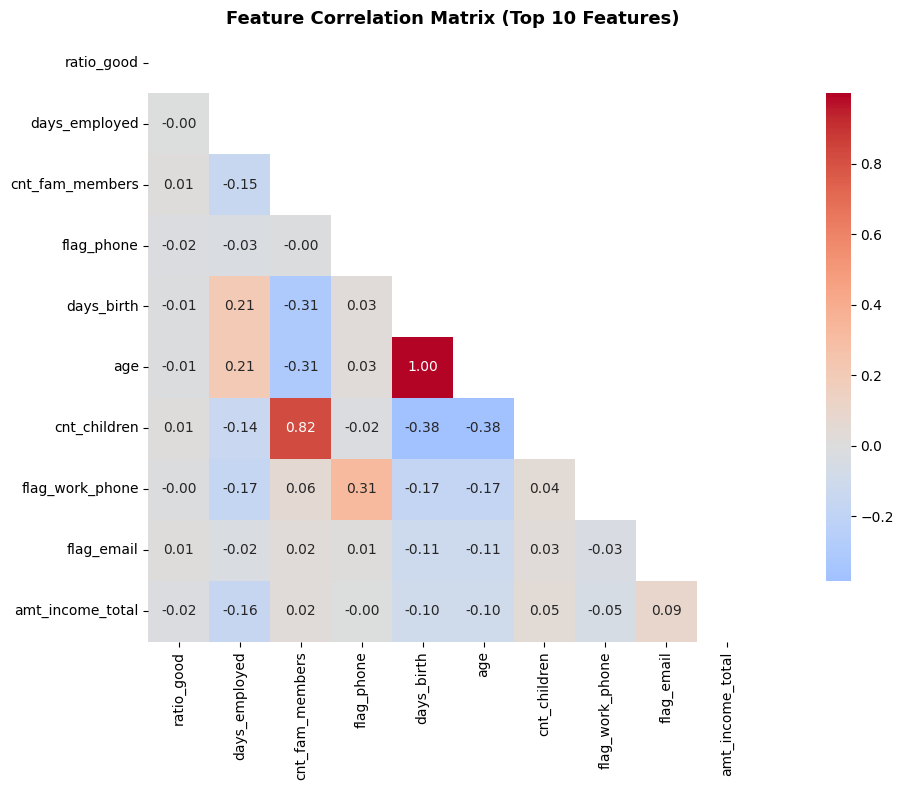


⚠ High correlation pairs (>|0.8|):
  cnt_fam_members ↔ cnt_children: 0.824
  days_birth ↔ age: 1.000

Top predictive features stored for later modeling:
['ratio_good', 'days_employed', 'cnt_fam_members', 'flag_phone', 'days_birth', 'age', 'cnt_children', 'flag_work_phone', 'flag_email', 'amt_income_total', 'ratio_unknown']
========== CORRELATION ANALYSIS COMPLETED ==========


In [8]:
print("=" * 10, "FEATURE CORRELATION ANALYSIS", "=" * 10)

# 1️⃣ Remove ID column if exists
ID_COLUMNS = ["id", "ID", "customer_id", "account_id"]
df_model = df.drop(columns=[c for c in ID_COLUMNS if c in df.columns])

# 2️⃣ Select numeric features
numeric_for_correlation = [f for f in NUMERIC_FEATURES if f in df_model.columns]

if len(numeric_for_correlation) > 0:

    # ===============================
    # 3️⃣ Correlation with target
    # ===============================

    # Ensure target_features is not duplicated in the list for correlation calculation
    features_to_correlate = [f for f in numeric_for_correlation if f != target_features]
    features_to_correlate.append(target_features)

    # Calculate correlations and explicitly ensure it's a Series before sorting
    correlations = (
        df_model[features_to_correlate]
        .corr(method="spearman")[target_features]
        .abs()
    )
    correlations = pd.Series(correlations).sort_values(ascending=False)

    # Remove target itself
    top_corr_features = correlations.drop(target_features)

    print("\nTop features correlated with target:")
    print(top_corr_features.head(10))

    # ===============================
    # 4️⃣ Feature-Feature correlation
    # ===============================

    top_10_features = top_corr_features.head(10).index.tolist()
    corr_matrix = df_model[top_10_features].corr(method="spearman")
    plt.figure(figsize=(14, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", center=0, square=True, fmt=".2f", cbar_kws={"shrink": .8})
    plt.title("Feature Correlation Matrix (Top 10 Features)", fontsize = 13, weight="bold")
    plt.tight_layout()
    plt.show()

    # ===============================
    # 5️⃣ Identify highly correlated pairs
    # ===============================

    threshold = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > threshold:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], corr_value)
                )

    if high_corr_pairs:
        print(f"\n⚠ High correlation pairs (>|{threshold}|):")
        for feat1, feat2, corr in high_corr_pairs:
            print(f"  {feat1} ↔ {feat2}: {corr:.3f}")

    else:
        print("\n✓ No high correlation pairs found")

    # ===============================
    # 6️⃣ Store top predictive features
    # ===============================

    TOP_PREDICTIVE_FEATURES = top_corr_features.head(20).index.tolist()

    print("\nTop predictive features stored for later modeling:")
    print(TOP_PREDICTIVE_FEATURES)

print("=" * 10, "CORRELATION ANALYSIS COMPLETED", "=" * 10)

========== ANALYSIS BY FEATURE GROUP ==========

DEMOGRAPHIC - NUMERIC FEATURES (3):
       cnt_children  cnt_fam_members       age
count      32047.00         32047.00  32047.00
mean           0.43             2.20     43.36
std            0.74             0.91     11.52
min            0.00             1.00     21.00
25%            0.00             2.00     34.00
50%            0.00             2.00     42.00
75%            1.00             3.00     53.00
max           19.00            20.00     68.00


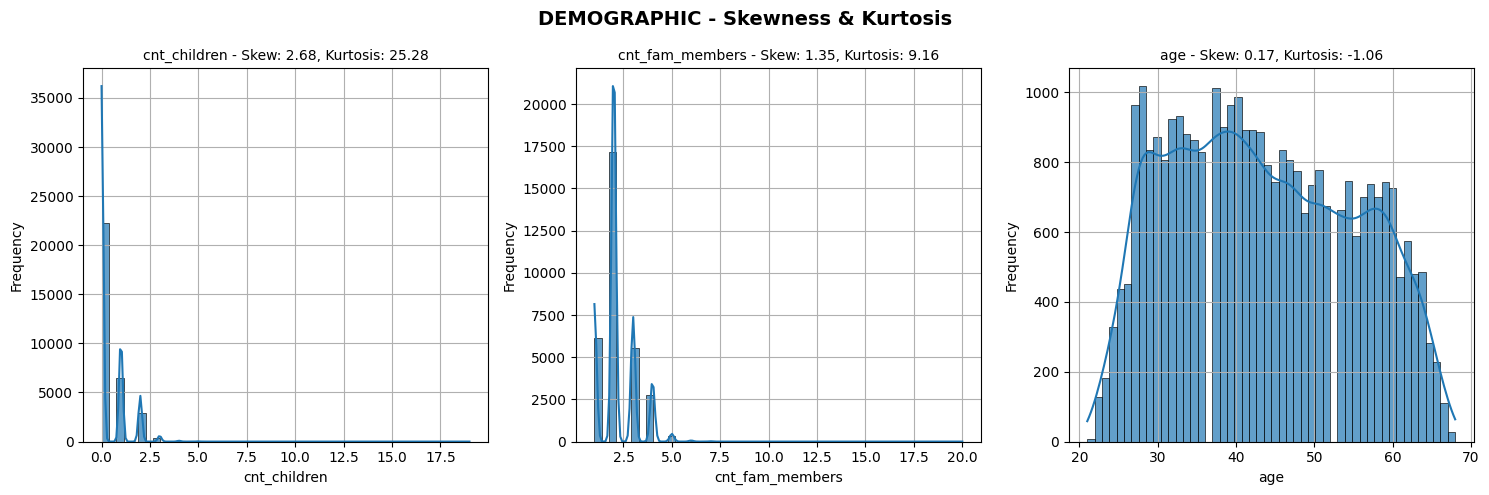


DEMOGRAPHIC - CATEGORICAL FEATURES (1):

code_gender (2 unique values):
code_gender
F    21496
M    10551
Name: count, dtype: int64


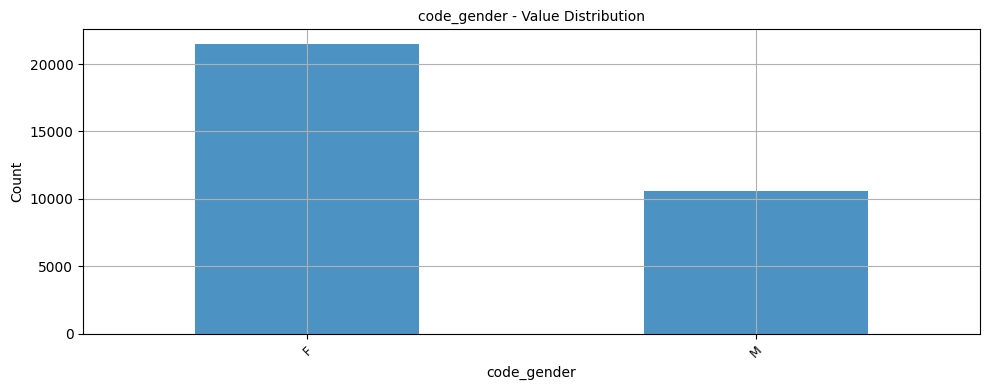


FINANCIAL - NUMERIC FEATURES (1):
       amt_income_total
count          32047.00
mean          186324.38
std           101615.02
min            27000.00
25%           121500.00
50%           157500.00
75%           225000.00
max          1575000.00


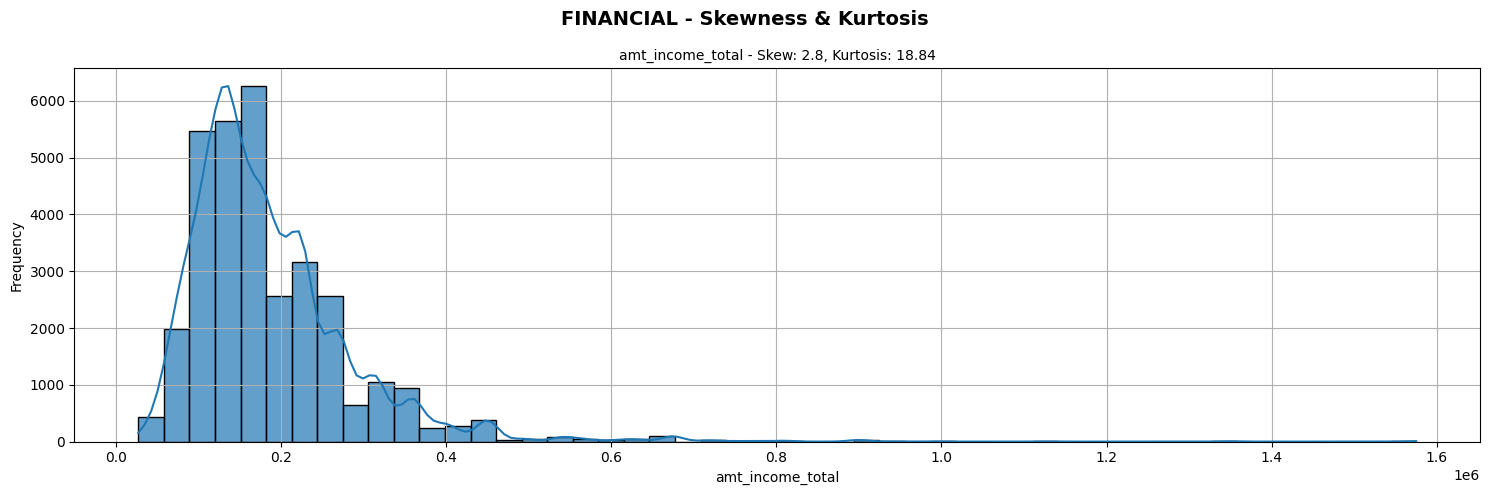


FINANCIAL - CATEGORICAL FEATURES (4):

name_income_type (5 unique values):
name_income_type
Working                 16575
Commercial associate     7408
Pensioner                5430
State servant            2623
Student                    11
Name: count, dtype: int64


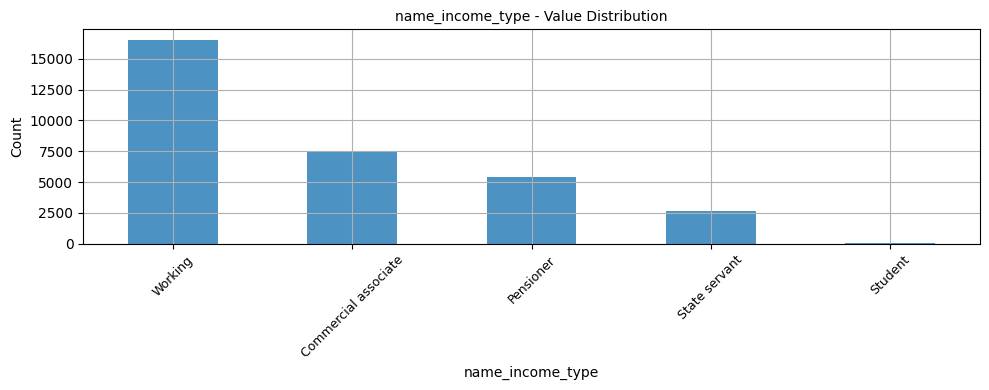


name_education_type (5 unique values):
name_education_type
Secondary / secondary special    21787
Higher education                  8634
Incomplete higher                 1259
Lower secondary                    338
Academic degree                     29
Name: count, dtype: int64


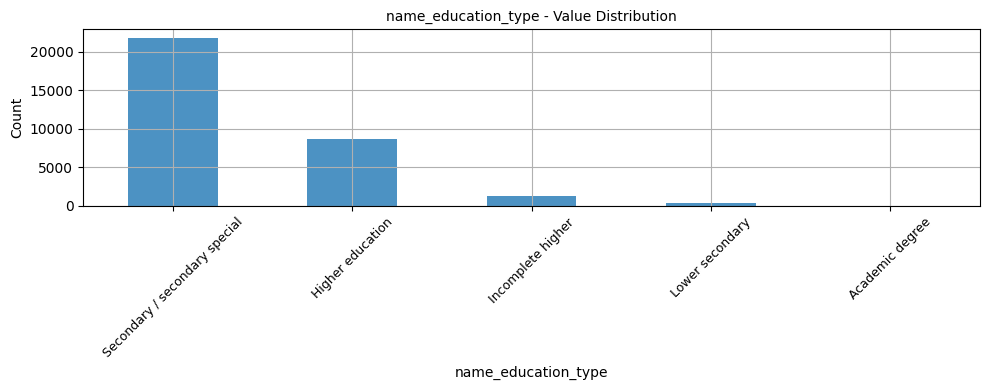


name_family_status (5 unique values):
name_family_status
Married                 22068
Single / not married     4232
Civil marriage           2555
Separated                1851
Widow                    1341
Name: count, dtype: int64


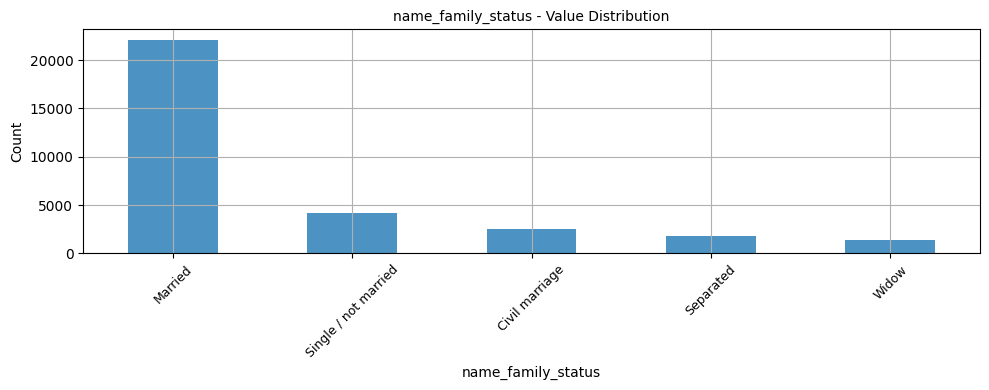


name_housing_type (6 unique values):
name_housing_type
House / apartment      28638
With parents            1543
Municipal apartment      995
Rented apartment         505
Office apartment         238
Co-op apartment          128
Name: count, dtype: int64


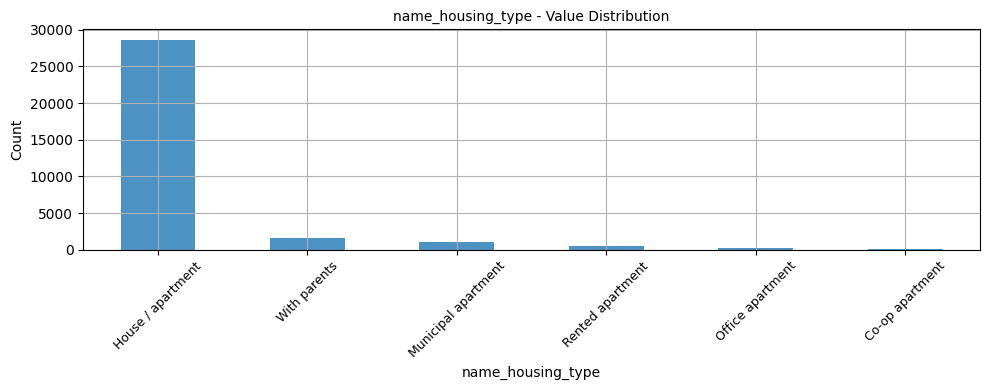


EMPLOYMENT - NUMERIC FEATURES (1):
       days_employed
count       32047.00
mean        59470.18
std        137866.92
min        -15713.00
25%         -3173.00
50%         -1567.00
75%          -412.00
max        365243.00


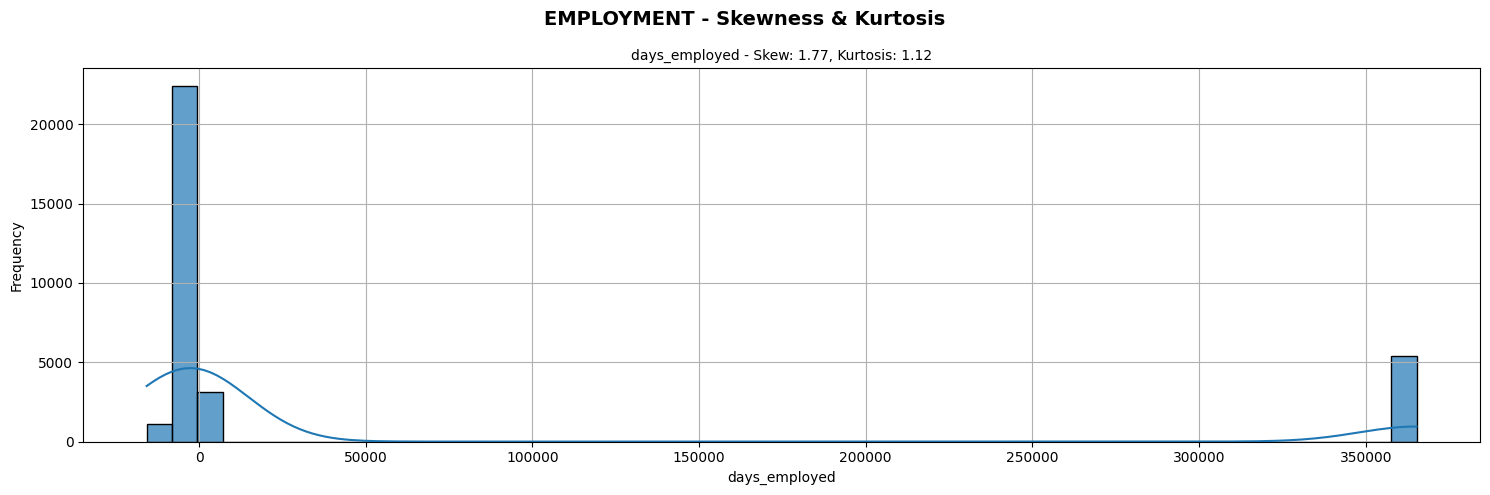


EMPLOYMENT - CATEGORICAL FEATURES (1):

occupation_type (18 unique values):
occupation_type
Laborers                 5378
Core staff               3190
Sales staff              3004
Managers                 2642
Drivers                  1877
High skill tech staff    1247
Medicine staff           1097
Accountants              1071
Cooking staff             569
Security staff            543
Name: count, dtype: int64


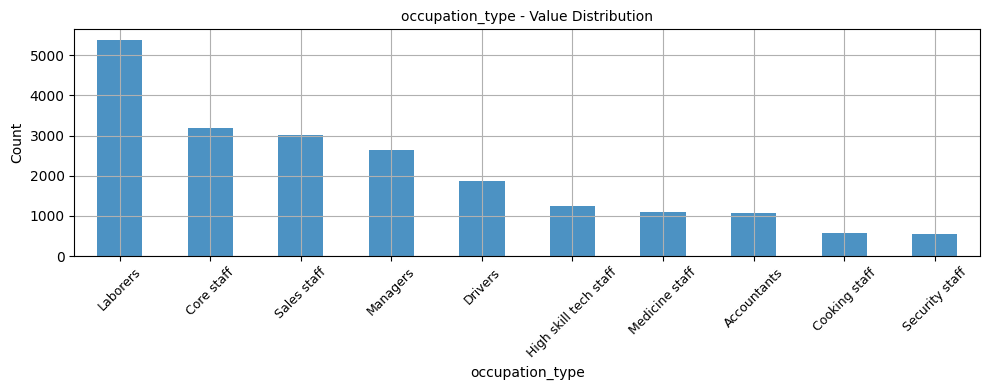


CONTACT - NUMERIC FEATURES (3):
       flag_work_phone  flag_email  flag_phone
count         32047.00    32047.00    32047.00
mean              0.23        0.09        0.29
std               0.42        0.29        0.46
min               0.00        0.00        0.00
25%               0.00        0.00        0.00
50%               0.00        0.00        0.00
75%               0.00        0.00        1.00
max               1.00        1.00        1.00


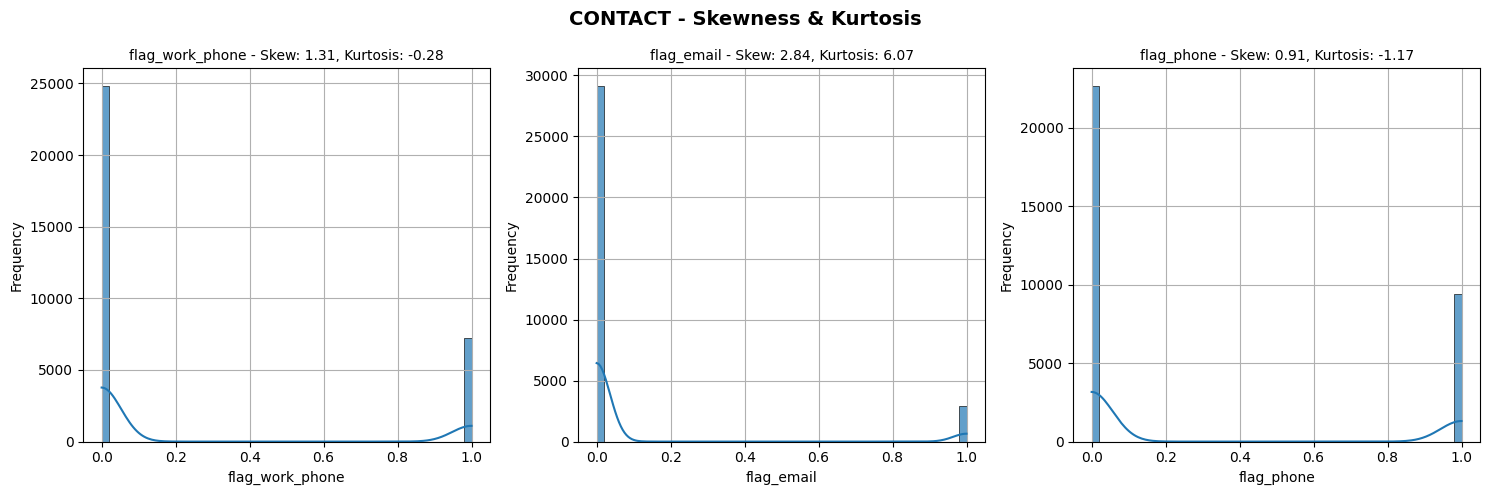


CONTACT - CATEGORICAL FEATURES (2):

flag_own_car (2 unique values):
flag_own_car
N    19884
Y    12163
Name: count, dtype: int64


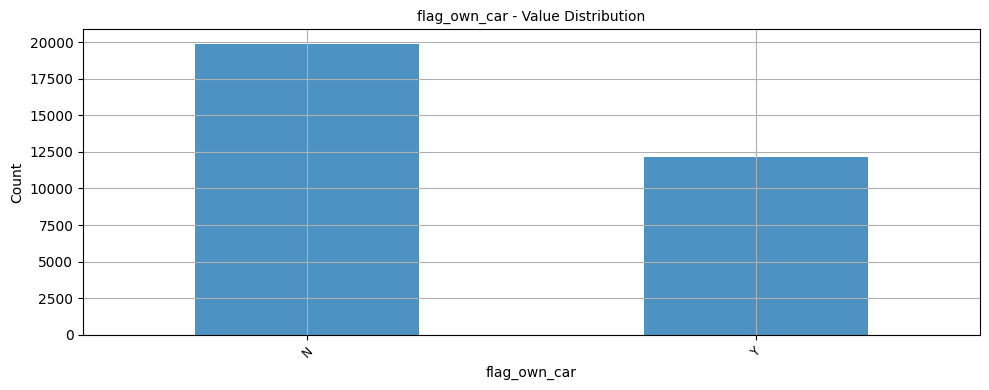


flag_own_realty (2 unique values):
flag_own_realty
Y    21527
N    10520
Name: count, dtype: int64


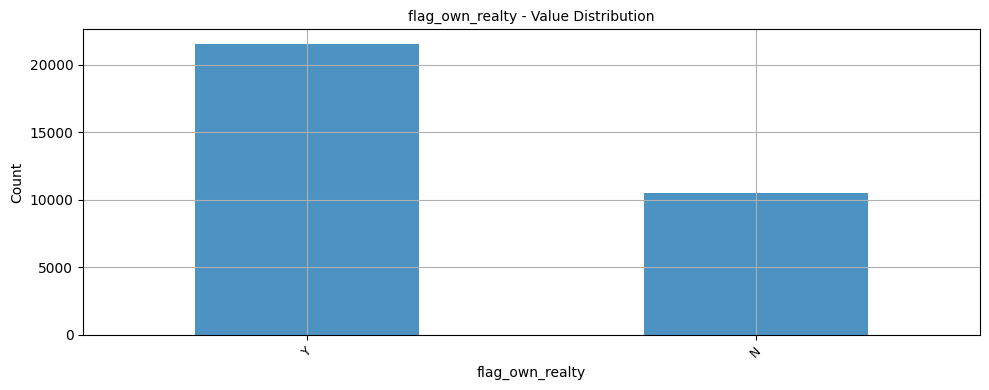


CC_HISTORY - NUMERIC FEATURES (2):
       ratio_unknown  ratio_good
count       32047.00    32047.00
mean            0.12        0.86
std             0.21        0.22
min             0.00        0.00
25%             0.00        0.81
50%             0.00        0.96
75%             0.15        1.00
max             0.98        1.00


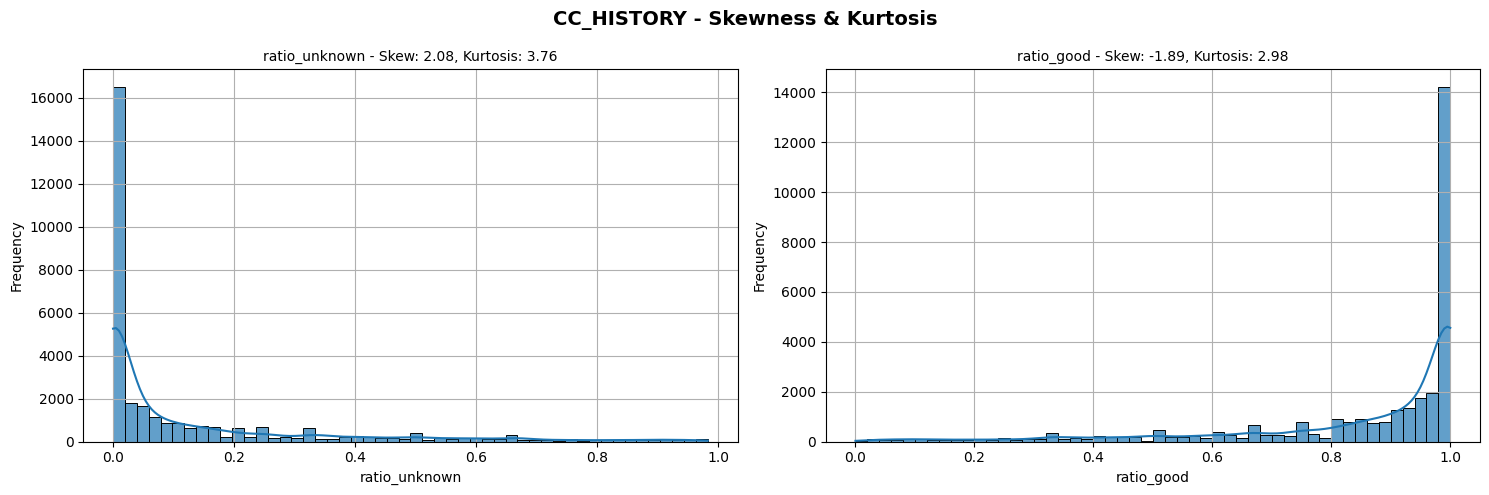

No categorical features to visualize in cc_history


In [9]:
print("=" * 10, "ANALYSIS BY FEATURE GROUP" ,"=" * 10)

def visualization_numeric_features(features, group_name):
  if not features:
    print(f"No numeric features to visualize in {group_name}")
    return

  print(f"\n{group_name.upper()} - NUMERIC FEATURES ({len(features)}):")

  # Statistical summary
  summary_stats = df[features].describe().round(2)
  print(summary_stats)

  # Distribution analysis
  n_features = len(features)
  if n_features >= 1:
    n_cols = min(3, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize = (15, 5 * n_rows))
    if n_rows == 1 and n_cols == 1:
      axes = [axes]
    elif n_rows == 1:
      axes = axes.flatten()
    else:
      axes = axes.flatten()

    for i, feature in enumerate(features):
      if i < len(axes):
        # Distribution plot
        sns.histplot(data=df[feature], kde=True, ax=axes[i], alpha=0.7, bins=50)

        # Statistics
        skew = df[feature].skew().round(2)
        kurtosis = df[feature].kurtosis().round(2)

        axes[i].set_title(f"{feature} - Skew: {skew}, Kurtosis: {kurtosis}", fontsize = 10)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Frequency")
        axes[i].grid(True)

    for i in range(len(features), len(axes)):
      fig.delaxes(axes[i])

    plt.suptitle(f"{group_name.upper()} - Skewness & Kurtosis", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

def visualization_categorical_features(features, group_name):
  # Analyze categorical features with value counts
  if not features:
    print(f"No categorical features to visualize in {group_name}")
    return

  print(f"\n{group_name.upper()} - CATEGORICAL FEATURES ({len(features)}):")

  for feature in features:
    plot_series = df[feature].fillna("Missing")

    value_counts = df[feature].value_counts()
    n_unique = df[feature].nunique()

    print(f"\n{feature} ({n_unique} unique values):")
    print(value_counts.head(10))

    # Visualize if reasonable number of categories
    if n_unique <= 20:
        plt.figure(figsize=(10, 4))
        value_counts.head(10).plot(kind='bar', alpha=0.8)
        plt.title(f'{feature} - Value Distribution', fontsize = 10)
        plt.xlabel(feature)
        plt.ylabel('Count')
        plt.xticks(rotation=45, fontsize=9)
        plt.tight_layout()
        plt.grid(True)
        plt.show()

# Analyze each feature group
for group_name, features in available_features.items():
    if features:
        # Split by type
        group_numeric = [f for f in features if f in NUMERIC_FEATURES]
        group_categorical = [f for f in features if f in CATEGORICAL_FEATURES]

        visualization_numeric_features(group_numeric, group_name)
        visualization_categorical_features(group_categorical, group_name)

**1.5: Bivariate Analysis - Features and Target**

========== BIVARIATE ANALYSIS - FEATURES AND TARGET ==========

BIVARIATE ANALYSIS TARGET - NUMERIC FEATURES (13):

ratio_good:
  Good customers: μ=0.86, σ=0.21
  Bad customers:  μ=0.54, σ=0.28
  Mann-Whitney p-value: 7.053e-109
  KS test p-value: 3.152e-103
  *** Highly significant difference

days_employed:
  Good customers: μ=59315.66, σ=137735.59
  Bad customers:  μ=75713.53, σ=150400.47
  Mann-Whitney p-value: 6.891e-06
  KS test p-value: 1.437e-06
  *** Highly significant difference

cnt_fam_members:
  Good customers: μ=2.20, σ=0.91
  Bad customers:  μ=2.10, σ=0.91
  Mann-Whitney p-value: 3.425e-02
  KS test p-value: 4.191e-01
  ** Significant difference

flag_phone:
  Good customers: μ=0.29, σ=0.45
  Bad customers:  μ=0.33, σ=0.47
  Mann-Whitney p-value: 1.103e-01
  KS test p-value: 6.510e-01
  No significant difference

days_birth:
  Good customers: μ=16007.23, σ=4202.84
  Bad customers:  μ=16416.55, σ=4354.72
  Mann-Whitney p-value: 1.119e-01
  KS test p-value: 1.066e-01
  No 

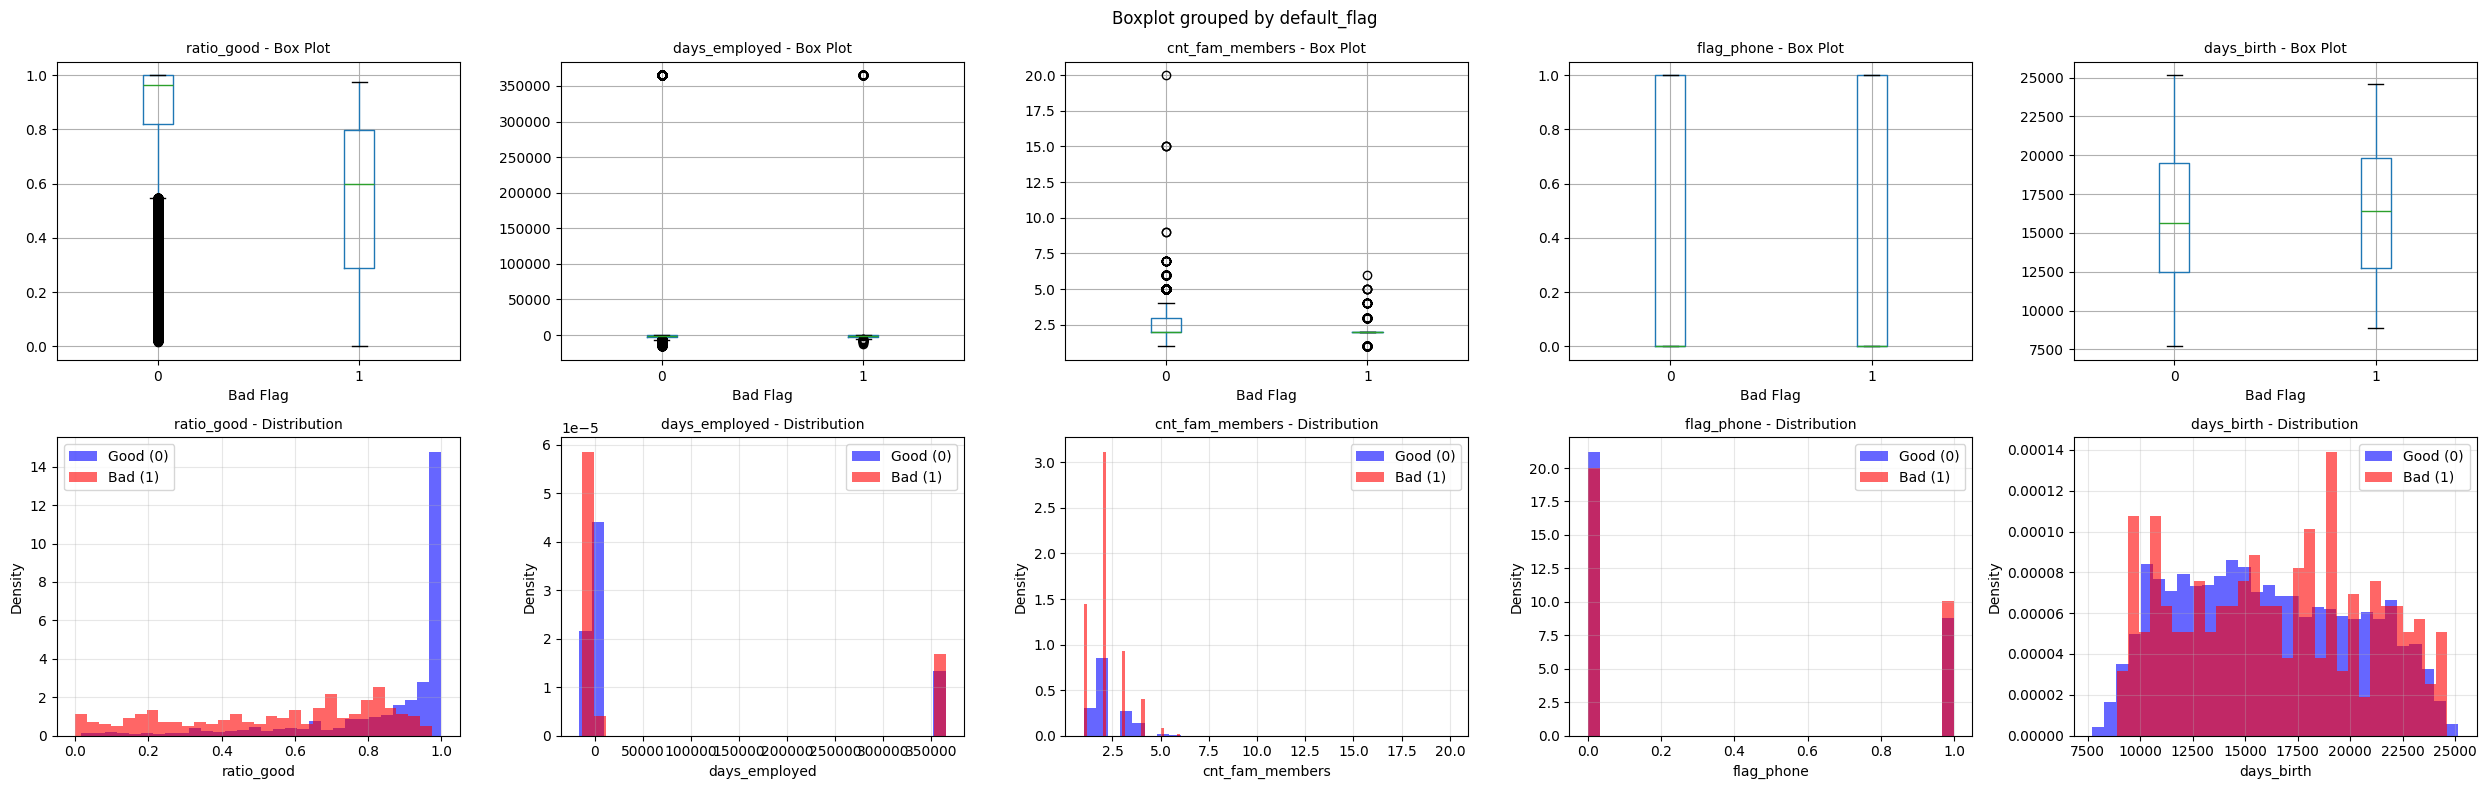


BIVARIATE ANALYSIS TARGET - CATEGORICAL FEATURES (8):

code_gender:
  Chi-square p-value: 4.802e-02
  Top 5 categories by bad rate:
             Total  Bad_Count  Bad_Rate
code_gender                            
M            10551        116    0.0110
F            21496        186    0.0087


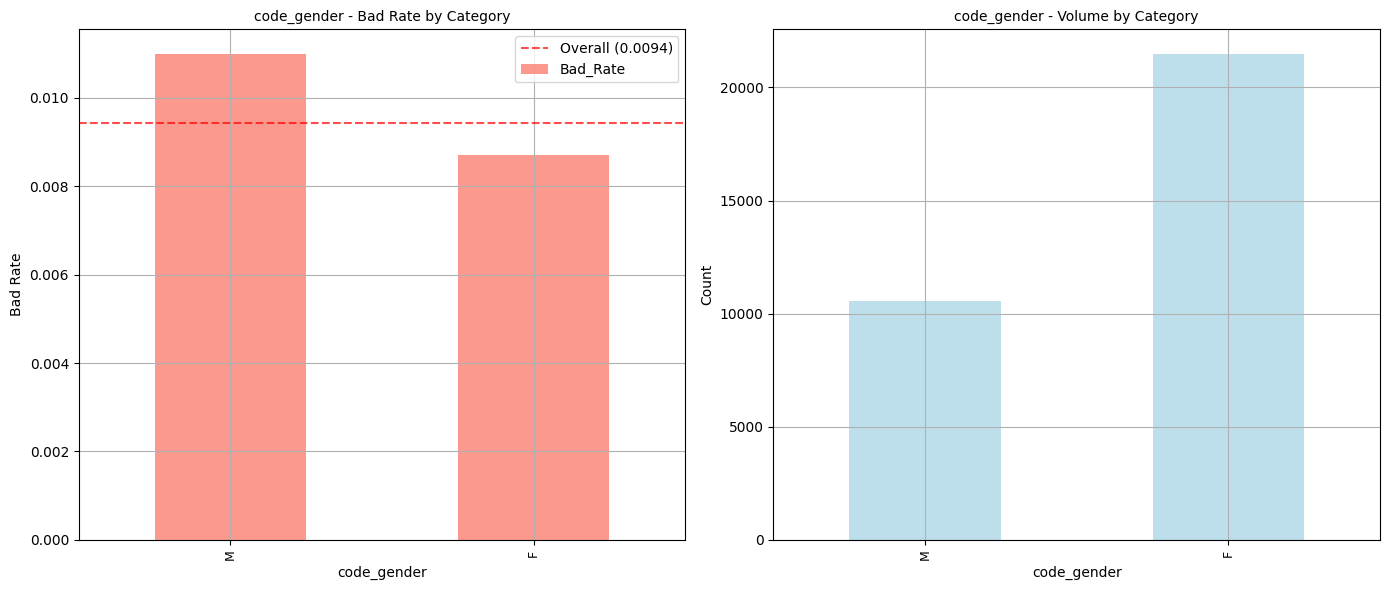


flag_own_car:
  Chi-square p-value: 3.963e-01
  Top 5 categories by bad rate:
              Total  Bad_Count  Bad_Rate
flag_own_car                            
N             19884        195    0.0098
Y             12163        107    0.0088


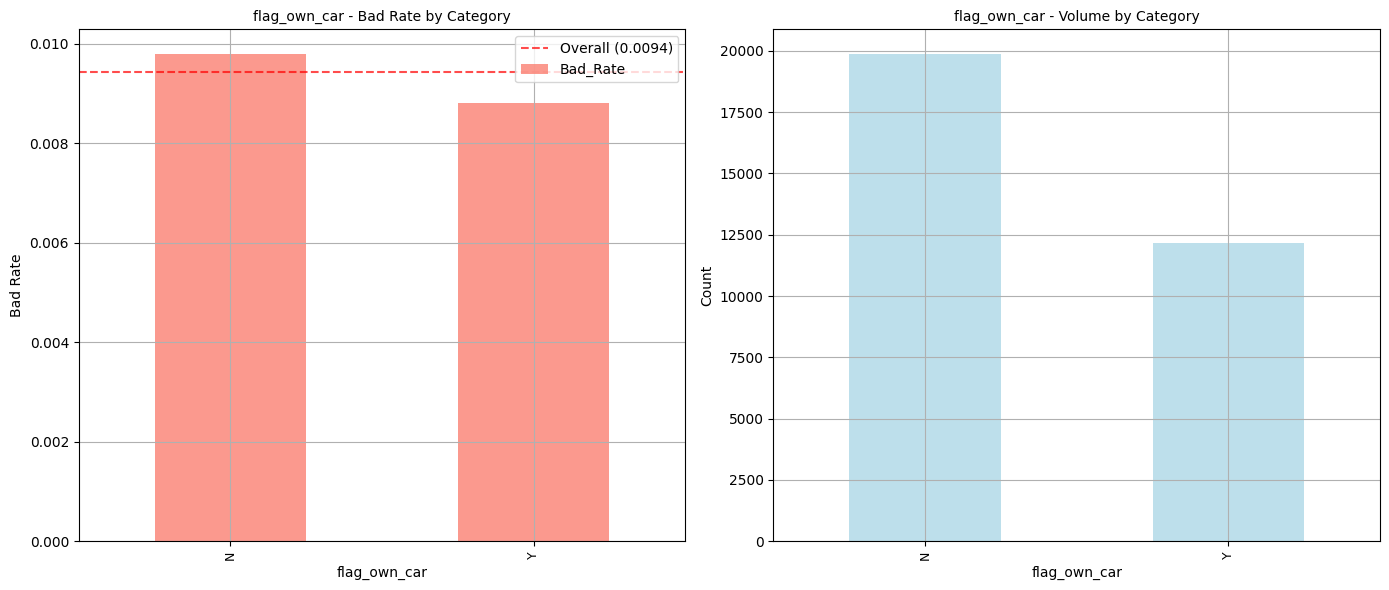


flag_own_realty:
  Chi-square p-value: 5.898e-03
  Top 5 categories by bad rate:
                 Total  Bad_Count  Bad_Rate
flag_own_realty                            
N                10520        122    0.0116
Y                21527        180    0.0084


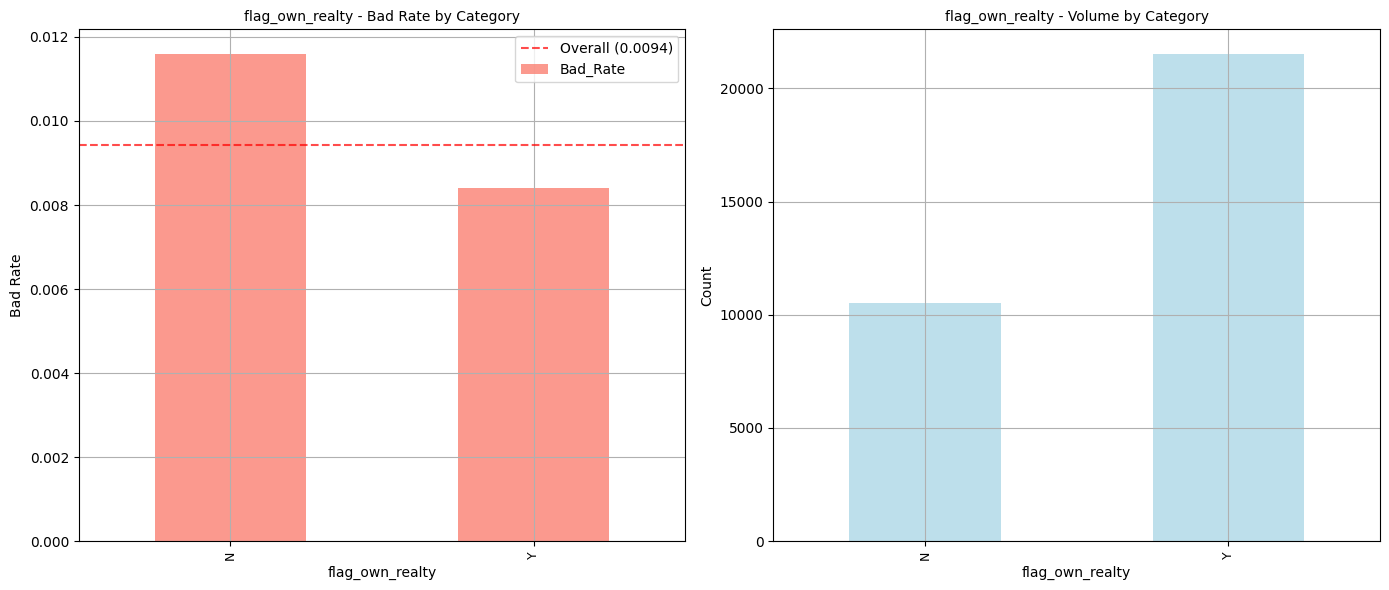


name_income_type:
  Chi-square p-value: 2.423e-03
  Top 5 categories by bad rate:
                      Total  Bad_Count  Bad_Rate
name_income_type                                
Pensioner              5430         71    0.0131
Commercial associate   7408         83    0.0112
Working               16575        129    0.0078
State servant          2623         19    0.0072
Student                  11          0    0.0000


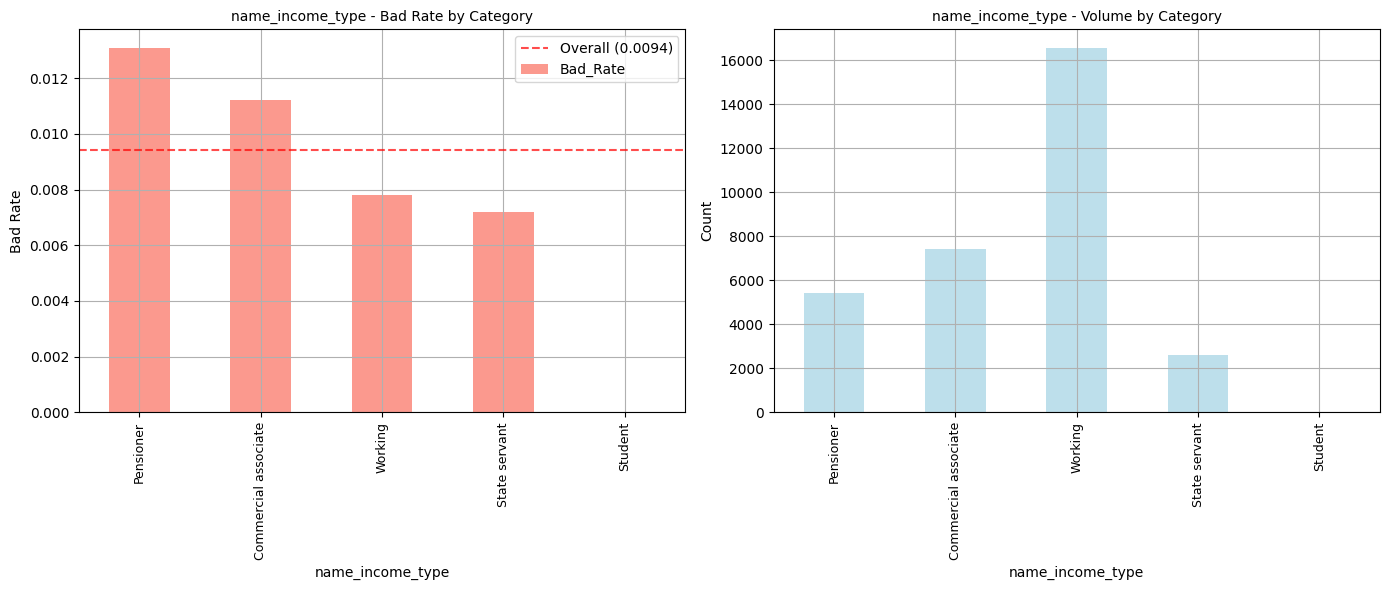


name_education_type:
  Chi-square p-value: 7.602e-03
  Top 5 categories by bad rate:
                               Total  Bad_Count  Bad_Rate
name_education_type                                      
Lower secondary                  338          7    0.0207
Incomplete higher               1259         20    0.0159
Higher education                8634         91    0.0105
Secondary / secondary special  21787        184    0.0084
Academic degree                   29          0    0.0000


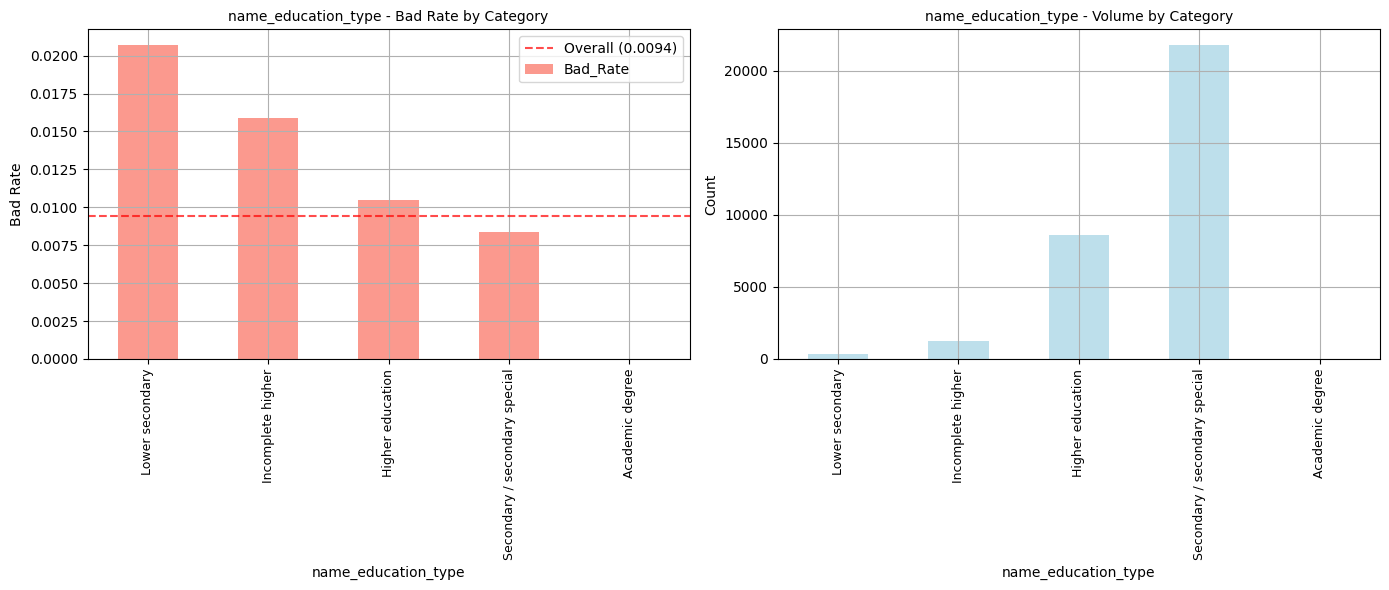

In [10]:
print("=" * 10, "BIVARIATE ANALYSIS - FEATURES AND TARGET", "=" * 10)
def visualization_bivariate_numeric(features, max_features):
  # Analyze numeric features and target with statistical
  if features.empty:
    return

  print(f"\nBIVARIATE ANALYSIS TARGET - NUMERIC FEATURES ({len(features)}):")

  if "TOP_PREDICTIVE_FEATURES" in globals():
    analysis_features = [f for f in TOP_PREDICTIVE_FEATURES if f in features][:max_features]
  else:
    analysis_features = features[:max_features]

  for feature in analysis_features:
    good_data = df[df[target_features] == 0][feature].dropna()
    bad_data = df[df[target_features] == 1][feature].dropna()

    # Statistical check
    try:
      mw_stat, mw_p = mannwhitneyu(good_data, bad_data, alternative = "two-sided")
      ks_stat, ks_p = ks_2samp(good_data, bad_data)

      print(f"\n{feature}:")
      print(f"  Good customers: μ={good_data.mean():.2f}, σ={good_data.std():.2f}")
      print(f"  Bad customers:  μ={bad_data.mean():.2f}, σ={bad_data.std():.2f}")
      print(f"  Mann-Whitney p-value: {mw_p:.3e}")
      print(f"  KS test p-value: {ks_p:.3e}")

      if mw_p < 0.001:
          print(f"  *** Highly significant difference")
      elif mw_p < 0.05:
          print(f"  ** Significant difference")
      else:
          print(f"  No significant difference")
    except Exception as e:
        print(f"\n{feature}: Unable to perform statistical tests - {e}")

  # Visualization
  if analysis_features:
      n_features_to_plot = len(analysis_features)
      fig, axes = plt.subplots(2, n_features_to_plot, figsize=(5*n_features_to_plot, 8))
      if n_features_to_plot == 1:
          axes = axes.reshape(-1, 1)

      for i, feature in enumerate(analysis_features):
          # Box plot
          df.boxplot(column=feature, by=target_features, ax=axes[0, i])
          axes[0, i].set_title(f'{feature} - Box Plot', fontsize=10)
          axes[0, i].set_xlabel('Bad Flag') # Label still refers to bad flag conceptually

          # Histogram overlay
          good_data_hist = df[df[target_features] == 0][feature].dropna()
          bad_data_hist = df[df[target_features] == 1][feature].dropna()

          axes[1, i].hist(good_data_hist, bins=30, alpha=0.6, label='Good (0)', density=True, color='blue')
          axes[1, i].hist(bad_data_hist, bins=30, alpha=0.6, label='Bad (1)', density=True, color='red')
          axes[1, i].set_title(f'{feature} - Distribution', fontsize=10)
          axes[1, i].set_xlabel(feature)
          axes[1, i].set_ylabel('Density')
          axes[1, i].legend()
          axes[1, i].grid(alpha=0.3)

      plt.tight_layout()
      plt.show()

def visualization_bivariate_categorical(features, max_features):
  # Analyze categorical features and target with bad_rate
  if features.empty:
    return

  print(f"\nBIVARIATE ANALYSIS TARGET - CATEGORICAL FEATURES ({len(features)}):")
  analysis_features = features[:max_features]

  for feature in analysis_features:
      # Chi-square test
      try:
          contingency = pd.crosstab(df[feature], df[target_features])
          chi2, p_value, dof, expected = chi2_contingency(contingency)

          # Bad rate by category
          bad_rate_analysis = df.groupby(feature)[target_features].agg(['count', 'sum', 'mean']).round(4)
          bad_rate_analysis.columns = ['Total', 'Bad_Count', 'Bad_Rate']
          bad_rate_analysis = bad_rate_analysis.sort_values('Bad_Rate', ascending=False)

          print(f"\n{feature}:")
          print(f"  Chi-square p-value: {p_value:.3e}")
          print(f"  Top 5 categories by bad rate:")
          print(bad_rate_analysis.head())

          # Visualization
          plt.figure(figsize=(14, 6))

          plt.subplot(1, 2, 1)
          bad_rate_analysis['Bad_Rate'].head(10).plot(kind='bar', color='salmon', alpha=0.8)
          plt.title(f'{feature} - Bad Rate by Category', fontsize = 10)
          plt.ylabel('Bad Rate', fontsize = 10)
          plt.xticks(rotation=90, fontsize=9)
          plt.axhline(y=df[target_features].mean(), color='red', linestyle='--', alpha=0.7,
                      label=f'Overall ({df[target_features].mean():.4f})')
          plt.grid()
          plt.legend()

          plt.subplot(1, 2, 2)
          bad_rate_analysis['Total'].head(10).plot(kind='bar', color='lightblue', alpha=0.8)
          plt.title(f'{feature} - Volume by Category', fontsize = 10)
          plt.ylabel('Count', fontsize=10)
          plt.xticks(rotation=90, fontsize=9)
          plt.grid()
          plt.tight_layout()
          plt.show()

      except Exception as e:
          print(f"\n{feature}: Unable to perform chi-square test - {e}")

visualization_bivariate_numeric(NUMERIC_FEATURES, 5)
visualization_bivariate_categorical(CATEGORICAL_FEATURES, 5)

# 2. Feature Engineering and Processing

**2.1: Data Leakage detection and processing**

In [11]:
print("=" * 10, "FEATURE LEAKAGE DETECTION (ADVANCED FEATURE ENGINEERING)" ,"=" * 10)

def advanced_feature_engineering(df, target_col="bad_flag"):
    df_fe = df.copy()

    # 1. Remove ID columns
    id_cols = [col for col in df_fe.columns if "id" in col.lower()]
    if id_cols:
        print("1. Removing ID columns:", id_cols)
        df_fe.drop(columns=id_cols, inplace=True)

    # 2. Handle missing values
    print("2. Handling missing values...")
    numeric_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df_fe.select_dtypes(include=["object"]).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)

    # numeric → median
    for col in numeric_cols:
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())
    # categorical → Unknown
    for col in categorical_cols:
        df_fe[col] = df_fe[col].fillna("Unknown")

    # 3. Handle outliers using IQR clipping
    print("3. Handling outliers...")
    for col in numeric_cols:
        Q1 = df_fe[col].quantile(0.25)
        Q3 = df_fe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_fe[col] = df_fe[col].clip(lower, upper)

    # 4. Simple domain features
    print("4. Creating domain features...")
    if "amt_income_total" in df_fe.columns and "cnt_children" in df_fe.columns:
        df_fe["income_per_child"] = df_fe["amt_income_total"] / (df_fe["cnt_children"] + 1)
    if "age" in df_fe.columns:
        df_fe["young_customer"] = (df_fe["age"] < 30).astype(int)

    print("5. Transform Skew features...")
    for column in numeric_cols:
        s = df_fe[column].skew()
        k = df_fe[column].kurtosis()
        # 1. If both are extreme (Skew > 2 and Kurt > 3)
        if abs(s) > 2 and abs(k) > 3:
            print(f"--> Heavy handling for {column}: Applying Yeo-Johnson (Power Transformer)")
            pt = PowerTransformer(method='yeo-johnson')
            df_fe[column] = pt.fit_transform(df_fe[[column]])

        # 2. If only highly skewed (Skew > 2) but tails are not too heavy
        elif abs(s) > 2:
            if (df_fe[column] > 0).all():
                print(f"--> Handling right skew for {column}: Applying Log Transformation")
                df_fe[column] = np.log1p(df_fe[column])
            else:
                print(f"--> Handling skew with negative values for {column}: Applying Cube Root")
                df_fe[column] = np.cbrt(df_fe[column])

        # 3. If only heavy-tailed (High Kurtosis) but Skewness is normal
        elif abs(k) > 3:
            print(f"--> Handling heavy tails for {column}: Applying RobustScaler to mitigate Outliers")
            scaler = RobustScaler()
            df_fe[column] = scaler.fit_transform(df_fe[[column]])

        # 4. If the distribution is relatively stable
        else:
            print(f"--> Stable distribution for {column}: No specific transformation applied")

    print("\nFeature engineering completed.")
    print("New dataset shape:", df_fe.shape)
    return df_fe

df_processed = advanced_feature_engineering(df, target_col="default_flag")

print("\n", "=" * 10, "FEATURE SELECTION - NO DATA LEAKAGE" ,"=" * 10)

forbidden_features = ["id", "default_flag", "flag_mobil", "days_birth", "cnt_children"]

# Add any ID-like columns
forbidden_features.extend([col for col in df_processed.columns if 'id' in col.lower()])

# Add any columns with "application" in name (potential leakage)
forbidden_features.extend([col for col in df_processed.columns if 'application' in col.lower()])

# Remove duplicates and filter existing columns
forbidden_features = [col for col in set(forbidden_features) if col in df_processed.columns]

print(f"Forbidden features (data leakage risk): {forbidden_features}")

# Get safe modeling features
safe_features = [col for col in df_processed.columns if col not in forbidden_features]

print(f"Safe features for modeling ({len(safe_features)}): {safe_features}")

# Further filter based on data availability and quality
modeling_features = []
for col in safe_features:
    missing_pct = df_processed[col].isnull().sum() / len(df_processed)
    if missing_pct < 0.95:  # Keep features with <95% missing
        modeling_features.append(col)
    else:
        print(f"Excluding {col} due to high missing rate: {missing_pct:.2%}")

feature_string = ", ".join(f'"{c}"' for c in modeling_features)
feature_wrapped = textwrap.fill(feature_string, width=220)

print("\nFinal modeling features:", len(modeling_features))
print("List features:", feature_wrapped)

========== FEATURE LEAKAGE DETECTION (ADVANCED FEATURE ENGINEERING) ==========
1. Removing ID columns: ['id']
2. Handling missing values...
3. Handling outliers...
4. Creating domain features...
5. Transform Skew features...
--> Stable distribution for cnt_children: No specific transformation applied
--> Stable distribution for amt_income_total: No specific transformation applied
--> Stable distribution for days_birth: No specific transformation applied
--> Stable distribution for days_employed: No specific transformation applied
--> Stable distribution for flag_work_phone: No specific transformation applied
--> Stable distribution for flag_phone: No specific transformation applied
--> Stable distribution for flag_email: No specific transformation applied
--> Stable distribution for cnt_fam_members: No specific transformation applied
--> Stable distribution for ratio_unknown: No specific transformation applied
--> Stable distribution for ratio_good: No specific transformation applied
-

**2.2: Split data**

In [12]:
print("=" * 10, "SPLIT DATA AND SUMMARY FEATURES FOR TRAINING MODEL", "=" * 10)

X = df_processed[modeling_features].copy()
y = df_processed[target_features]

# Train test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\n1. Perform train-test split...")
print(f"Using {len(modeling_features)} features for modeling")
print(f"Initial modeling dataset: X={X.shape}, y={y.shape}")
print(f"Overall bad rate: {y.mean():.4f}")

print("\n2. Final data quality verification...")
print(f"Train set: X={x_train.shape}, y={y_train.shape}, bad_rate={y_train.mean():.4f}")
print(f"Test set:  X={x_test.shape}, y={y_test.shape}, bad_rate={y_test.mean():.4f}")

# Missing values
train_missing = x_train.isnull().sum().sum()
test_missing = x_test.isnull().sum().sum()

print("\n3. Missing values analysis...")
print(f"Missing values in train set: {train_missing}")
print(f"Missing values in test set: {test_missing}")

categorical_modeling_features = x_train.select_dtypes(include=['object']).columns.tolist()
numeric_modeling_features = x_train.select_dtypes(include=['int64','float64']).columns.tolist()

if train_missing > 0 or test_missing > 0:
    print("Processing missing values...")

    # categorical
    for col in categorical_modeling_features:
        x_train[col].fillna("Unknown", inplace=True)
        x_test[col].fillna("Unknown", inplace=True)

    # numeric
    for col in numeric_modeling_features:
        median_value = x_train[col].median()
        x_train[col].fillna(median_value, inplace=True)
        x_test[col].fillna(median_value, inplace=True)

print("\n4. Class distribution:")
print("Train:", y_train.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

# Import preprocessor components here, after numeric_modeling_features and categorical_modeling_features are defined
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_modeling_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_modeling_features)
    ],
    remainder='passthrough'
)

========== SPLIT DATA AND SUMMARY FEATURES FOR TRAINING MODEL ==========

1. Perform train-test split...
Using 19 features for modeling
Initial modeling dataset: X=(32047, 19), y=(32047,)
Overall bad rate: 0.0094

2. Final data quality verification...
Train set: X=(24035, 19), y=(24035,), bad_rate=0.0094
Test set:  X=(8012, 19), y=(8012,), bad_rate=0.0095

3. Missing values analysis...
Missing values in train set: 0
Missing values in test set: 0

4. Class distribution:
Train: default_flag
0    0.990597
1    0.009403
Name: proportion, dtype: float64
Test: default_flag
0    0.990514
1    0.009486
Name: proportion, dtype: float64


**2.4: Feature selections from Logistic Regression - WOE and IV Analysis**

* The objective of this section is to analyze the relationship between
individual features and the target variable.
* This helps identify variables with strong predictive power
and detect potential monotonic relationships for credit scoring.


========== FEATURE SELECTION AND WOE ANALYSIS WITH LOGISTIC REGRESSION ==========
1. Feature selection from Logistic Regression and correlation

==== Logistic Regression Feature Importance ====
           Feature  Coefficient  abs_coef
0       ratio_good    -8.703958  8.703958
8    ratio_unknown    -8.533442  8.533442
3       flag_phone     0.431443  0.431443
2  cnt_fam_members     0.253175  0.253175
4              age     0.043950  0.043950
1    days_employed     0.000029  0.000029

2. WOE (Weight of Evidence) and IV (Information Value) analysis
Feature: ratio_good
Information Value: 2.2789
                count  bad   good  good_dist  bad_dist       WOE        IV
ratio_good_bin                                                            
(-0.001, 0.75]   6899  211   6688   0.210679  0.698675 -1.198848  0.585034
(0.75, 0.92]     5926   81   5845   0.184123  0.268212 -0.376169  0.031631
(0.92, 1.0]     19222   10  19212   0.605198  0.033113  2.905613  1.662258
Feature: ratio_unknown
Inf

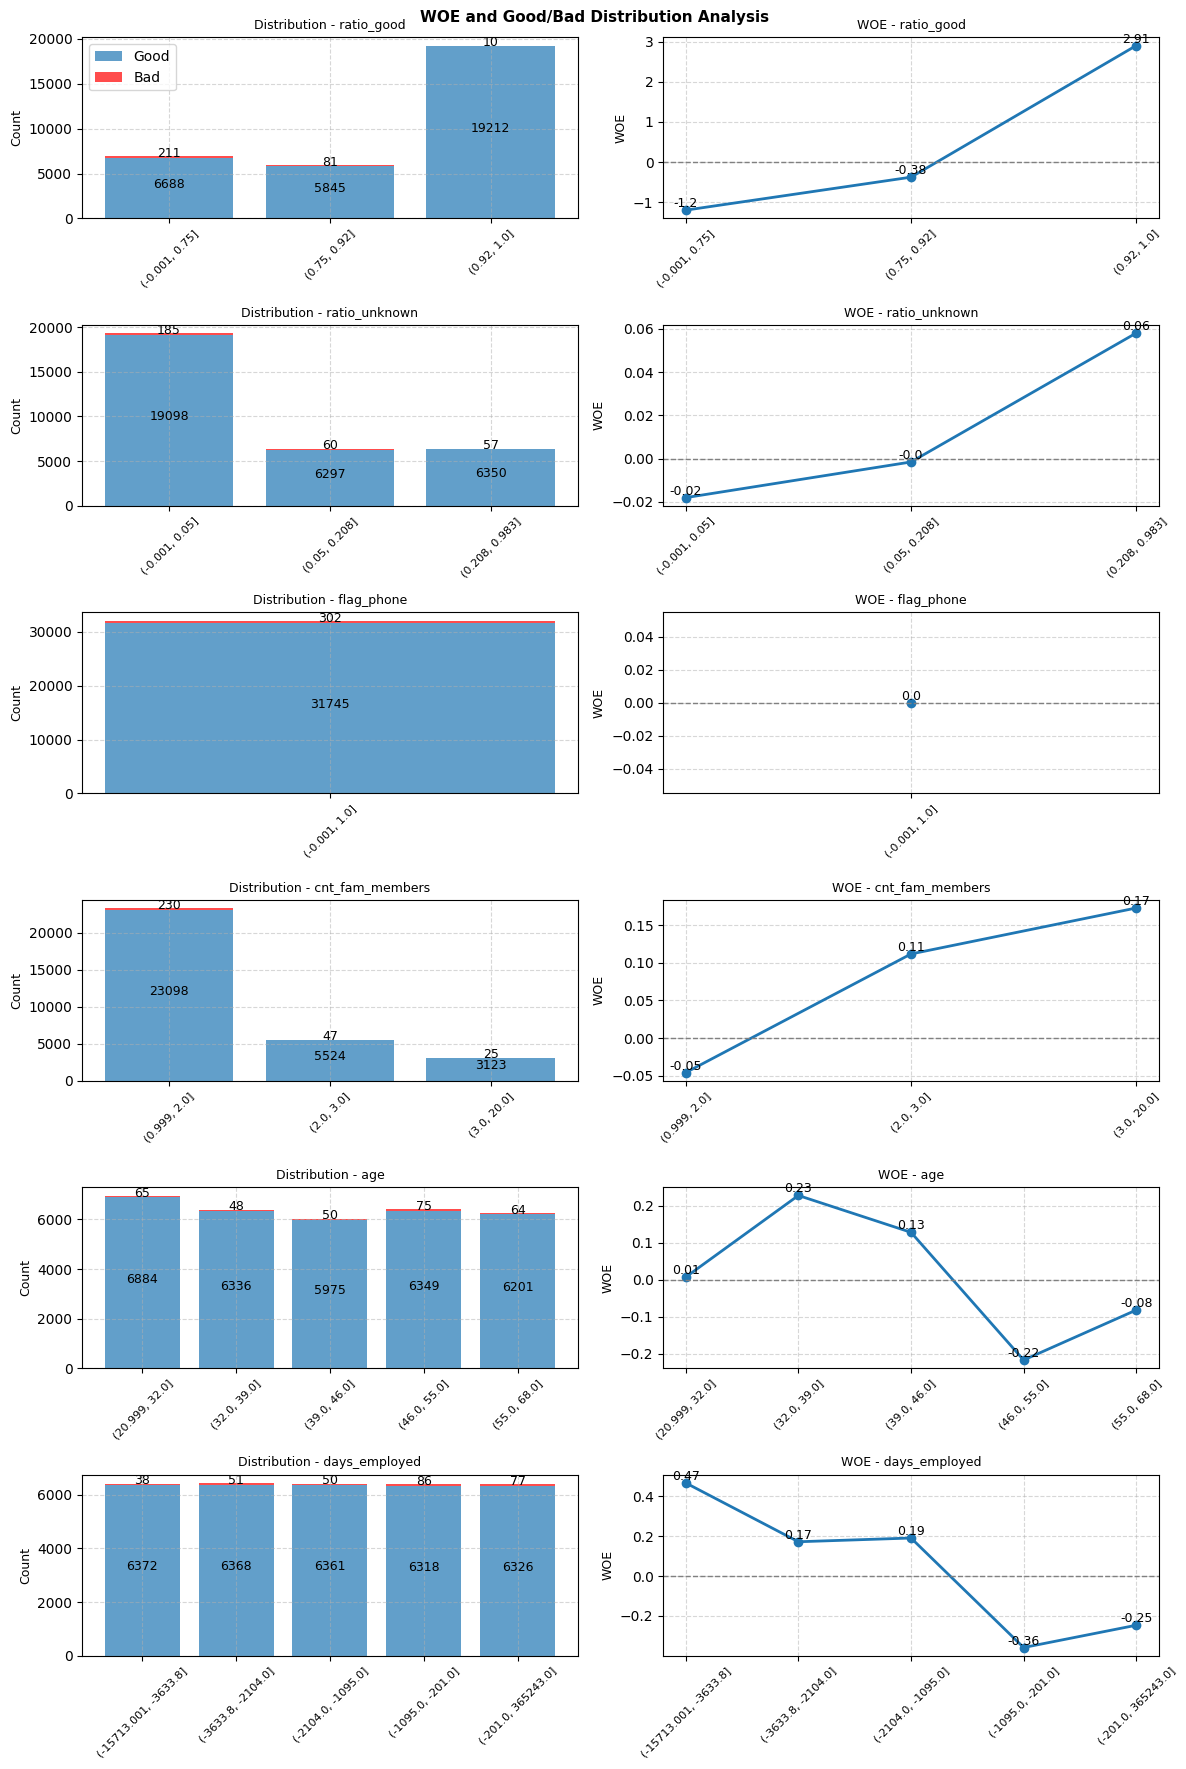

In [13]:
print("=" * 10, "FEATURE SELECTION AND WOE ANALYSIS WITH LOGISTIC REGRESSION" ,"=" *10)

print("1. Feature selection from Logistic Regression and correlation")
# Filter TOP_PREDICTIVE_FEATURES to only include columns present in x_train
current_top_predictive_features = [f for f in TOP_PREDICTIVE_FEATURES if f in x_train.columns]

# Split features and target using filtered features and y_train
x_woe_selected = x_train[current_top_predictive_features].copy()
y_woe_selected = y_train.copy()

# Identify categorical columns
categorical_cols = x_woe_selected.select_dtypes(include=['object']).columns

# Convert categorical columns to 'category' dtype (for get_dummies)
for col in categorical_cols:
    x_woe_selected[col] = x_woe_selected[col].astype("category")

# One-hot encode categorical features for Logistic Regression
x_lr = pd.get_dummies(x_woe_selected, drop_first=True)

# Train Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_lr.fit(x_lr, y_woe_selected) # Use x_lr for fitting

# Feature importance
importance = pd.DataFrame({
    "Feature": x_lr.columns, # Use columns from x_lr
    "Coefficient": model_lr.coef_[0]
})

importance["abs_coef"] = importance["Coefficient"].abs()
importance = importance.sort_values("abs_coef", ascending=False)

print("\n==== Logistic Regression Feature Importance ====")
print(importance.head(6))
selected_features = importance.head(6)["Feature"].tolist()

print("\n2. WOE (Weight of Evidence) and IV (Information Value) analysis")

def woe_calculations(data, feature, target):
    # Binning (with numeric)
    if data[feature].dtype != 'object':
        data[feature+"_bin"] = pd.qcut(data[feature], q=5, duplicates='drop', retbins=False)
        grouped = data.groupby(feature+"_bin")[target]
    else:
        grouped = data.groupby(feature)[target]

    df_woe = pd.DataFrame()
    df_woe["count"] = grouped.count()
    df_woe["bad"] = grouped.sum()
    df_woe["good"] = df_woe["count"] - df_woe["bad"]

    df_woe["good_dist"] = df_woe["good"] / df_woe["good"].sum()
    df_woe["bad_dist"] = df_woe["bad"] / df_woe["bad"].sum()

    eps = 1e-6
    df_woe["WOE"] = np.log((df_woe["good_dist"]+eps) / (df_woe["bad_dist"]+eps))
    df_woe["IV"] = (df_woe["good_dist"] - df_woe["bad_dist"]) * df_woe["WOE"]
    iv = df_woe["IV"].sum()

    return df_woe, iv

woe_results = {}

# For WOE calculation, we use the original 'df' and target_features
# 'selected_features' now comes from the LR model trained on x_train, so they are guaranteed to be in df_processed, and thus in df.
for feature in [f for f in selected_features if f in df.columns]: # Ensure feature is in original df for WOE calculations
    woe_table, iv = woe_calculations(df, feature, target_features)
    print("==============================")
    print(f"Feature: {feature}")
    print("Information Value:", round(iv,4))
    print(woe_table)
    woe_results[feature] = woe_table

# Plot distribution + WOE together
n_features = len(selected_features)
cols = 2
rows = n_features
fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 3))

# Fix case when only 1 feature
if rows == 1:
    axes = [axes]

for i, feature in enumerate(selected_features):
    if feature not in woe_results: # Skip if WOE was not calculated for this feature
        continue
    woe_table = woe_results[feature]
    x = range(len(woe_table))

    # 1️⃣ Distribution plot
    axes[i][0].bar(x, woe_table["good"], label="Good", alpha=0.7)
    axes[i][0].bar(x, woe_table["bad"], bottom=woe_table["good"], label="Bad", alpha=0.7, color="red")
    axes[i][0].set_title(f"Distribution - {feature}", fontsize=9)
    axes[i][0].set_ylabel("Count", fontsize=9)
    axes[i][0].set_xticks(x)
    axes[i][0].set_xticklabels(woe_table.index.astype(str), rotation=45, fontsize=8)
    axes[i][0].grid(True, linestyle="--", alpha=0.5)

    # Show values on bars
    for j, (g, b) in enumerate(zip(woe_table["good"], woe_table["bad"])):
        axes[i][0].text(j, g/2, int(g), ha="center", color="black", fontsize=9)
        axes[i][0].text(j, g + b/2, int(b), ha="center", color="black", fontsize=9)

    if i == 0:
        axes[i][0].legend()

    # 2️⃣ WOE plot
    axes[i][1].plot(x, woe_table["WOE"], marker="o", linewidth=2)
    axes[i][1].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[i][1].set_title(f"WOE - {feature}", fontsize=9)
    axes[i][1].set_ylabel("WOE", fontsize=9)
    axes[i][1].set_xticks(x)
    axes[i][1].set_xticklabels(woe_table.index.astype(str), rotation=45, fontsize=8)
    axes[i][1].grid(True, linestyle="--", alpha=0.5)

    # Show WOE values
    for j, val in enumerate(woe_table["WOE"]) :
        axes[i][1].text(j, val, round(val,2), ha="center", va="bottom", fontsize=9)

fig.suptitle("WOE and Good/Bad Distribution Analysis", fontsize=11, weight="bold")
plt.tight_layout()
plt.show()

# 3. Model training and prediction

**3.2: Model training**

In [14]:
def create_credit_model(model_type, imbalance_strategy):
  # Logistic Regression
  if model_type == 'logistic':
      base_params = {
          'random_state': RANDOM_STATE,
          'solver': 'liblinear',
          'max_iter': 300,
          'C':0.5
      }
      if imbalance_strategy == 'class_weight':
          base_params['class_weight'] = 'balanced'

      model = LogisticRegression(**base_params)
      model_name = "LogisticRegression"

  # Random Forest
  elif model_type == 'random_forest':
      base_params = {
          'n_estimators': 250,
          'max_depth': 6,
          'min_samples_leaf': 20,
          'min_samples_split': 40,
          'max_features': "sqrt",
          'random_state': RANDOM_STATE,
          'n_jobs': -1
      }

      if imbalance_strategy == 'class_weight':
          base_params['class_weight'] = 'balanced'

      model = RandomForestClassifier(**base_params)
      model_name = "RandomForest"

  # LightGBM
  elif model_type == "LightGBM":
        base_param = {
          "n_estimators":300,
          "learning_rate":0.05,
          "max_depth":6,
          "num_leaves":20,
          "min_child_samples":100,
          "subsample":0.8,
          "colsample_bytree":0.8,
          "reg_alpha":0.1,
          "reg_lambda":1,
          "objective":"binary",
          "verbosity":-1,
          "max_bin" : 255,
          "random_state":RANDOM_STATE,
          "n_jobs":-1
        }
        if imbalance_strategy == "class_weight":
            base_param["class_weight"] = "balanced"

        model = lgb.LGBMClassifier(**base_param)
        model_name = "LightGBM"

  # XGBoost
  elif model_type == 'xgboost':
      GOOD_COUNT = (y_train == 0).sum()
      BAD_COUNT = (y_train == 1).sum()
      scale_pos_weight = GOOD_COUNT / BAD_COUNT
      base_params = {
          'learning_rate': 0.05,
          'n_estimators': 200,
          'max_depth': 5,
          'min_child_weight': 5,
          'subsample': 0.8,
          'colsample_bytree': 0.8,
          'scale_pos_weight': scale_pos_weight,
          'eval_metric': 'logloss',
          'random_state': RANDOM_STATE
      }

      model = XGBClassifier(**base_params)
      model_name = "XGBoost"

  else:
      raise ValueError(f"Unknown model type: {model_type}")

  # Create Pipeline
  if imbalance_strategy == 'smote':
      pipeline = ImbPipeline([
          ('preprocessor', preprocessor),
          ('smote', SMOTE(sampling_strategy=0.01,random_state=RANDOM_STATE)),
          ('classifier', model)
      ])
  else:
      pipeline = SkPipeline([
          ('preprocessor', preprocessor),
          ('classifier', model)])
  return pipeline, model_name

**3.3: Model Computations**

In [15]:
@dataclass
class RiskMetricsResult:
  model: str
  imbalance_data: str
  accuracy: float
  precision: float
  recall: float
  f1: float
  roc_auc: float
  ks_score: float
  gini: float

def model_computations(model, data_imbalances, y_true, y_pred, threshold = 0.5):
  # Comprehensive evaluation for churn model
  y_pred = (y_pred >= threshold).astype(int)

  # Basic metrics
  TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)

  # Metrics AUC and GINI
  roc_auc = roc_auc_score(y_true, y_pred)
  gini = 2 * roc_auc - 1

  # KS Score
  FPR, TPR, _ = roc_curve(y_true, y_pred)
  ks_score = max(TPR - FPR)

  return RiskMetricsResult(model, data_imbalances, accuracy, precision,
                           recall, f1, roc_auc, ks_score, gini)

def psi_calculations(expected, actual, bins = 10):
  """
  Calculate Population Stability Index (PSI) with handling for duplicate bin edges
  PSI < 0.1: Stable
  0.1 <= PSI < 0.25: Monitor required
  PSI >= 0.25: Investigate required
  """
  # Define breakpoints using quantiles from the expected distribution
  breakpoints_quantiles = np.linspace(0, 1, bins + 1)
  bin_edges = np.unique(np.quantile(expected, breakpoints_quantiles))

  # Add -inf and inf to cover all values
  bin_edges = np.concatenate([[-np.inf], bin_edges, [np.inf]])

  # Calculate the distribution (counts) for expected and actual data within these bins
  expected_counts = np.histogram(expected, bins=bin_edges)[0]
  actual_counts = np.histogram(actual, bins=bin_edges)[0]

  # Convert counts to percentages
  expected_percent = expected_counts / len(expected)
  actual_percent = actual_counts / len(actual)

  # Add a small constant to zero percentages to avoid log(0) and division by zero
  epsilon = 1e-5
  expected_percent = np.where(expected_percent == 0, epsilon, expected_percent)
  actual_percent = np.where(actual_percent == 0, epsilon, actual_percent)

  # Apply the PSI formula
  psi_value = np.sum((expected_percent - actual_percent) * np.log(expected_percent / actual_percent))
  return psi_value

In [16]:
def capture_rate(y_test, y_pred, ratio):
  cutoff = int(len(y_pred) * ratio)
  df = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
  df = df.sort_values('y_pred', ascending=False)
  capture_rate = df.head(cutoff)['y_test'].sum()
  total_churn = df['y_test'].sum()
  return capture_rate / total_churn if total_churn > 0 else np.nan

def find_best_threshold(y_test, y_prob):
  TPR, FPR, thresholds = roc_curve(y_test, y_prob)
  scores = [tpr - fpr for tpr, fpr in zip(TPR, FPR)]
  idx = np.argmax(scores)
  optimal_threshold = thresholds[idx]

  # Handle cases where optimal_threshold might be infinity, leading to zero positive predictions
  if np.isinf(optimal_threshold) or optimal_threshold > 1.0:
      # Find the highest finite threshold available
      finite_thresholds = thresholds[np.isfinite(thresholds)]
      if len(finite_thresholds) > 0:
          # Use the highest finite threshold (thresholds are typically sorted descending)
          return finite_thresholds[0]
      else:
          # Fallback to a default threshold if no finite thresholds are found
          return 0.5
  return optimal_threshold

# Cross-validation function
def cross_validate_model(pipeline, X, y, folds):
  skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
  auc, kss = [], []
  for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    # AUC
    auc.append(roc_auc_score(y_test, y_prob))
    # KS
    FPR, TPR, _ = roc_curve(y_test, y_prob)
    ks = np.max(TPR - FPR)
    kss.append(ks)
  return np.mean(auc), np.mean(kss)

**3.4: Results for Model**

In [17]:
# Train a model with all the combinations
print("=" * 10, "MODEL PERFORMANCE - USING PSI", "=" * 10)
model_types = ["logistic","random_forest","LightGBM","xgboost"]
imbalance_strategies = ["normal","smote","class_weight"]
n_splits = 5
results = []

# Initialize all_probs dictionary for storing test probabilities
all_probs = {}

for model_type in model_types:
    for strategy in imbalance_strategies:
      try:
        print(f"\nTraining {model_type} with {strategy}...")
        pipeline, model_name = create_credit_model(model_type, strategy)

        # Cross-validation (pipeline is refit internally)
        cv_auc, kss = cross_validate_model(pipeline, x_train, y_train, folds=n_splits)

        # Fit once on full training set for test evaluation
        pipeline.fit(x_train, y_train)

        # Predict
        y_train_prob = pipeline.predict_proba(x_train)[:, 1]
        y_test_prob = pipeline.predict_proba(x_test)[:, 1]

        # Store probabilities for calibration plots
        current_model_config_name = f"{model_name}_{strategy}"
        all_probs[current_model_config_name] = y_test_prob

        best_threshold = find_best_threshold(y_train, y_train_prob)
        y_test_pred = (y_test_prob >= best_threshold).astype(int)

        FN = ((y_test_pred == 0) & (y_test == 1)).sum()
        TP = ((y_test_pred == 1) & (y_test == 1)).sum()
        FNR = FN / (FN + TP) if FN + TP > 0 else np.nan

        # PR-AUC
        prec, rec, _ = precision_recall_curve(y_test, y_test_prob)
        pr_auc = auc_calculations(rec, prec)
        psi_value = psi_calculations(y_train_prob, y_test_prob, bins=10)
        result = model_computations(model_name, strategy, y_test, y_test_prob)

        # Brier score loss for training data
        brier = brier_score_loss(y_test, y_test_prob)

        # Capture rates
        capture_5 = capture_rate(y_test, y_test_prob, 0.05)
        capture_10 = capture_rate(y_test, y_test_prob, 0.1)
        capture_20 = capture_rate(y_test, y_test_prob, 0.2)

        res_dict = result.__dict__
        res_dict.update({
            "CV_AUC": cv_auc,
            "KSS": kss,
            "FNR": FNR,
            "PR_AUC": pr_auc,
            "BEST_THRESHOLD": best_threshold,
            "CAPTURE_5": capture_5,
            "CAPTURE_10": capture_10,
            "CAPTURE_20": capture_20,
            "PSI": psi_value,
            "BRIER": brier
        })
        results.append(res_dict)

        print(
            f"➤CV-AUC={cv_auc:.4f}, KSS={kss:.4f}, "
            f"TEST-AUC={result.roc_auc:.4f}, KS={result.ks_score:.4f}, "
            f"PSI={psi_value:.4f}, BRIER={brier:.4f}"
        )
        print(f"➤Capture_5%={capture_5:.2%}, " f"Capture_10%={capture_10:.2%}, " f"Capture_20%={capture_20:.2%}, ")

      except Exception as e:
        print(f"❌ Error training {model_name} with {strategy}: {e}")

========== MODEL PERFORMANCE - USING PSI ==========

Training logistic with normal...
➤CV-AUC=0.9387, KSS=0.7689, TEST-AUC=0.5973, KS=0.1946, PSI=0.0021, BRIER=0.0081
➤Capture_5%=67.11%, Capture_10%=78.95%, Capture_20%=96.05%, 

Training logistic with smote...
➤CV-AUC=0.9387, KSS=0.7729, TEST-AUC=0.5972, KS=0.1943, PSI=0.0023, BRIER=0.0082
➤Capture_5%=67.11%, Capture_10%=81.58%, Capture_20%=96.05%, 

Training logistic with class_weight...
➤CV-AUC=0.9523, KSS=0.8057, TEST-AUC=0.8552, KS=0.7103, PSI=0.0012, BRIER=0.0751
➤Capture_5%=75.00%, Capture_10%=81.58%, Capture_20%=97.37%, 

Training random_forest with normal...
➤CV-AUC=0.9239, KSS=0.7328, TEST-AUC=0.5000, KS=0.0000, PSI=0.0009, BRIER=0.0088
➤Capture_5%=65.79%, Capture_10%=75.00%, Capture_20%=84.21%, 

Training random_forest with smote...
➤CV-AUC=0.9241, KSS=0.7403, TEST-AUC=0.5000, KS=0.0000, PSI=0.0012, BRIER=0.0088
➤Capture_5%=67.11%, Capture_10%=72.37%, Capture_20%=86.84%, 

Training random_forest with class_weight...
➤CV-AUC=0

# 4. ROC for the best training

In [18]:
print("=" * 10, "EVALUATION METRICS", "=" * 10)

results_df = pd.DataFrame(results)
if len(results_df) > 0:
    # Corrected column names
    sort_cols = ['roc_auc', 'ks_score', 'CAPTURE_10', 'CV_AUC']
    results_df = results_df.sort_values(sort_cols, ascending=False)

    # Corrected display column names
    display_cols = ['model', 'imbalance_data',
                    'CV_AUC', 'KSS', 'roc_auc', 'ks_score',
                    'PSI',
                    'gini', 'CAPTURE_5', 'CAPTURE_10', 'CAPTURE_20']

    top_results = results_df[display_cols].head(15).round(4)
    styled_results = top_results.style.background_gradient(
        cmap='GnBu',
        subset=['CV_AUC', 'KSS', 'roc_auc', 'ks_score', 'CAPTURE_5', 'CAPTURE_10', 'CAPTURE_20']
    ).background_gradient(
        cmap='GnBu_r',  # Reverse colormap for PSI (lower is better)
        subset=['PSI']
    )
    display(styled_results)

    print(f"\nTotal models trained: {len(results_df)}")
    print(f"Best model: {results_df.iloc[0]['model']} "
          f"with {results_df.iloc[0]['imbalance_data']}")
    print(f"CV-AUC={results_df.iloc[0]['CV_AUC']:.4f}, "
          f"CV-KS={results_df.iloc[0]['KSS']:.4f}, "
          f"Test-AUC={results_df.iloc[0]['roc_auc']:.4f}, "
          f"KS={results_df.iloc[0]['ks_score']:.4f}")
    print(f"PSI={results_df.iloc[0]['PSI']:.4f}")
    print(f"Capture@5%={results_df.iloc[0]['CAPTURE_5']:.2%}")
    print(f"Capture@10%={results_df.iloc[0]['CAPTURE_10']:.2%}")
    print(f"Capture@20%={results_df.iloc[0]['CAPTURE_20']:.2%}")
else:
    print("\nNo models were successfully trained.")

========== EVALUATION METRICS ==========


,model,imbalance_data,CV_AUC,KSS,roc_auc,ks_score,PSI,gini,CAPTURE_5,CAPTURE_10,CAPTURE_20
10,XGBoost,smote,0.959100,0.812600,0.881300,0.762600,0.001900,0.762600,0.802600,0.855300,0.960500
8,LightGBM,class_weight,0.958600,0.811700,0.856400,0.712800,0.001400,0.712800,0.776300,0.855300,0.960500
2,LogisticRegression,class_weight,0.952300,0.805700,0.855200,0.710300,0.001200,0.710300,0.750000,0.815800,0.973700
9,XGBoost,normal,0.960100,0.822100,0.837200,0.674500,0.002200,0.674500,0.736800,0.868400,0.973700
11,XGBoost,class_weight,0.960100,0.822100,0.837200,0.674500,0.002200,0.674500,0.736800,0.868400,0.973700
5,RandomForest,class_weight,0.917300,0.715900,0.808900,0.617900,0.002500,0.617900,0.592100,0.697400,0.828900
7,LightGBM,smote,0.962200,0.816800,0.637500,0.275100,0.001200,0.275100,0.789500,0.881600,0.947400
6,LightGBM,normal,0.963200,0.827800,0.624500,0.249000,0.001700,0.249000,0.763200,0.881600,0.947400
0,LogisticRegression,normal,0.938700,0.768900,0.597300,0.194600,0.002100,0.194600,0.671100,0.789500,0.960500
1,LogisticRegression,smote,0.938700,0.772900,0.597200,0.194300,0.002300,0.194300,0.671100,0.815800,0.960500



Total models trained: 12
Best model: XGBoost with smote
CV-AUC=0.9591, CV-KS=0.8126, Test-AUC=0.8813, KS=0.7626
PSI=0.0019
Capture@5%=80.26%
Capture@10%=85.53%
Capture@20%=96.05%


========== ROC CURVE FOR THE BEST-PERFORMING TESTING MODEL ==========
Performance comparsion for top 3 models:
                                    auc  accuracy  precision  recall  f1_score
model                                                                         
XGBoost_smote                    0.8813    0.9584     0.1609  0.8026    0.2681
LightGBM_class_weight            0.8564    0.9737     0.2267  0.7368    0.3467
LogisticRegression_class_weight  0.8552    0.8938     0.0690  0.8158    0.1272


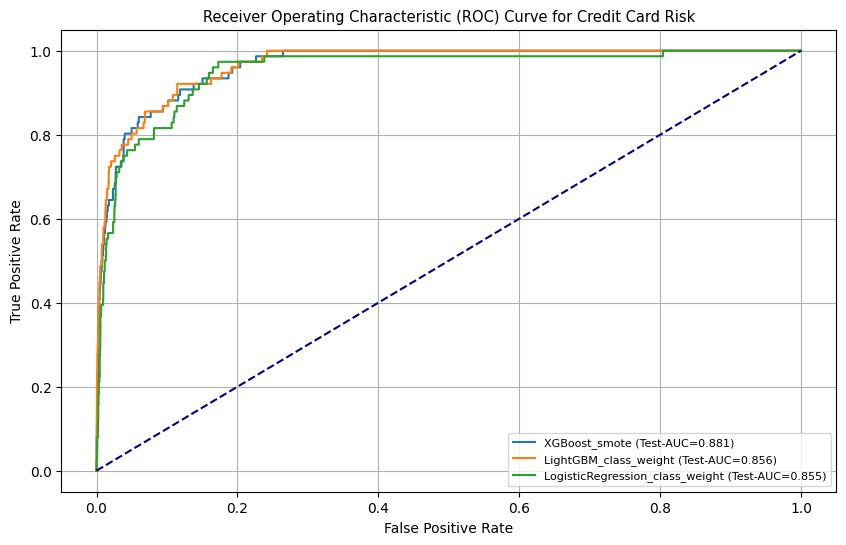

In [19]:
print("=" * 10, "ROC CURVE FOR THE BEST-PERFORMING TESTING MODEL", "=" * 10)
plt.figure(figsize=(10, 6))

# Get the top 3 model configurations (rows) from results_df
top3_models_data = results_df.sort_values("roc_auc", ascending=False).head(3)

# Extract keys in the format "ModelName_ImbalanceType" for all_probs lookup and plotting labels
top3_keys = [f"{row.model}_{row.imbalance_data}" for idx, row in top3_models_data.iterrows()]

# Prepare data for the model_comparsion DataFrame for printing specific metrics
model_comparsion_data_for_print = []

for idx, row in top3_models_data.iterrows():
    model_name = row['model']
    imbalance_type = row['imbalance_data']

    # Find the corresponding entry in the 'results' list
    found_result = next((res for res in results if res['model'] == model_name and res['imbalance_data'] == imbalance_type), None)
    if found_result:
        model_comparsion_data_for_print.append({
            'model': f"{model_name}_{imbalance_type}",
            'auc': found_result['roc_auc'],
            'accuracy': found_result['accuracy'],
            'precision': found_result['precision'],
            'recall': found_result['recall'],
            'f1_score': found_result['f1']
        })

# Create the DataFrame for printing, using 'model' as index
model_comparsion_df_for_print = pd.DataFrame(model_comparsion_data_for_print).set_index('model')

# Now print the desired metrics (using correct column names)
print("Performance comparsion for top 3 models:")
print(model_comparsion_df_for_print[["auc", "accuracy", "precision", "recall", "f1_score"]].round(4))

# Plotting ROC curves
for _, row in top3_models_data.iterrows():
    name = f"{row.model}_{row.imbalance_data}"
    y_prob = all_probs[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (Test-AUC={row.roc_auc:.3f})")

plt.plot([0, 1], [0, 1], color="navy", lw = 1.5, linestyle = "--")
plt.xlabel("False Positive Rate", fontsize=10)
plt.ylabel("True Positive Rate", fontsize=10)
plt.title("Receiver Operating Characteristic (ROC) Curve for Credit Card Risk", fontsize=10.5)
plt.legend(fontsize = 8)
plt.grid(True)
plt.show()

# 5. Risk group classifications

========== RISK GROUP CLASSIFICATIONS ==========

Best model: XGBoost (smote)
Test AUC: 0.8813


,risk_group,count,min_score,max_score,avg_score,bad_count,bad_rate,population_pct,bad_capture_pct,lift
3,Very High Risk,802,0.2148,0.9944,0.5260,65,0.0810,10.01,85.53,8.54
0,High Risk,1602,0.0156,0.2140,0.0650,11,0.0069,20.00,14.47,0.72
2,Medium Risk,1602,0.0031,0.0156,0.0079,0,0.0000,20.00,0.00,0.00
1,Low Risk,1602,0.0013,0.0031,0.0019,0,0.0000,20.00,0.00,0.00
4,Very Low Risk,2404,0.0001,0.0013,0.0008,0,0.0000,30.00,0.00,0.00


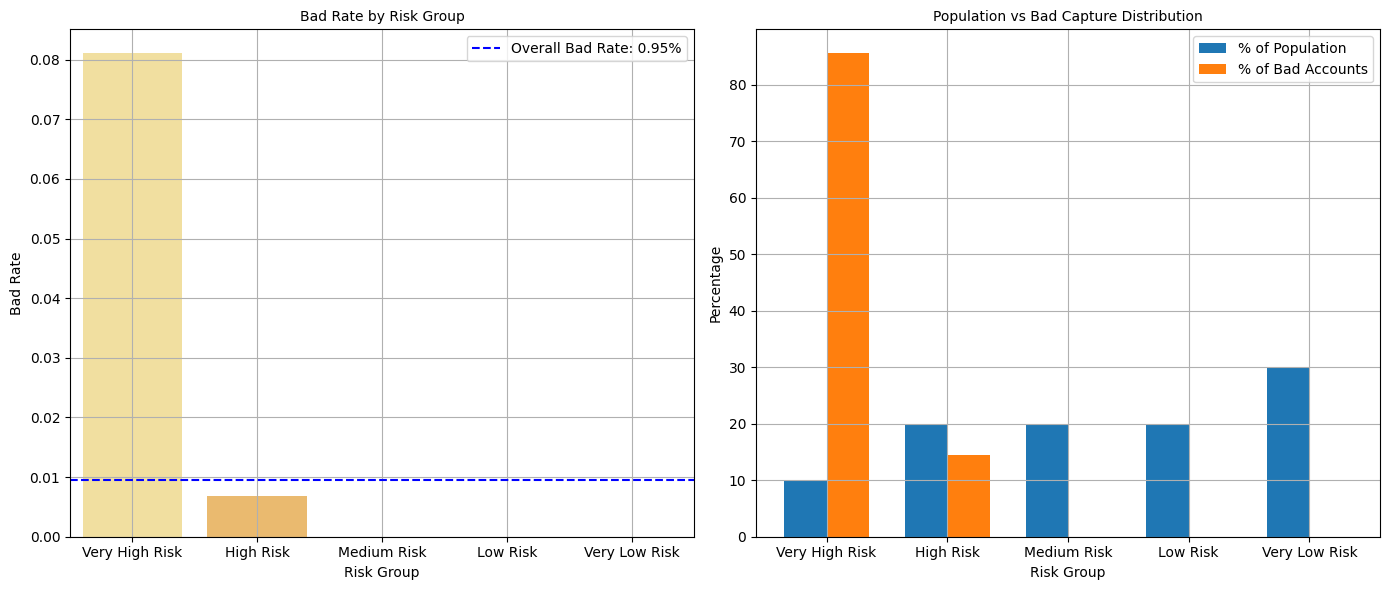

In [20]:
print("=" * 10, "RISK GROUP CLASSIFICATIONS", "=" * 10)
# 1. Select best model (based on TEST AUC)
best_model_info = results_df.sort_values("roc_auc", ascending=False).iloc[0]

best_model_name = best_model_info["model"]
best_imbalance = best_model_info["imbalance_data"]

print(f"\nBest model: {best_model_name} ({best_imbalance})")
print(f"Test AUC: {best_model_info['roc_auc']:.4f}")

# 2. Get predicted probabilities of best model
model_key = f"{best_model_name}_{best_imbalance}"

df_scores = pd.DataFrame({
    "score": all_probs[model_key],   # probability from best model
    "y_true": y_test
})

# Overall bad rate
overall_bad_rate = df_scores["y_true"].mean()

# 3. Create deciles (1 = lowest risk, 10 = highest risk)
df_scores["decile"] = pd.qcut(
    df_scores["score"],
    10,
    labels=range(1,11),
    duplicates="drop"
).astype(int)

# 4. Map decile → risk groups
def map_decile_to_group(d):
    if d == 10:
        return "Very High Risk"
    elif d in [8,9]:
        return "High Risk"
    elif d in [6,7]:
        return "Medium Risk"
    elif d in [4,5]:
        return "Low Risk"
    else:
        return "Very Low Risk"

df_scores["risk_group"] = df_scores["decile"].apply(map_decile_to_group)

# 5. Risk group statistics
risk_group_analysis = df_scores.groupby("risk_group").agg(
    count=("score","size"),
    min_score=("score","min"),
    max_score=("score","max"),
    avg_score=("score","mean"),
    bad_count=("y_true","sum"),
    bad_rate=("y_true","mean")).reset_index()

# 6. Additional metrics
risk_group_analysis["population_pct"] = (
    risk_group_analysis["count"] / len(df_scores) * 100).round(2)

risk_group_analysis["bad_capture_pct"] = (
    risk_group_analysis["bad_count"] /
    risk_group_analysis["bad_count"].sum() * 100).round(2)

risk_group_analysis["lift"] = (
    risk_group_analysis["bad_rate"] /
    overall_bad_rate).round(2)

# 7. Order risk groups
risk_order = ["Very High Risk","High Risk","Medium Risk","Low Risk","Very Low Risk"]

risk_group_analysis["risk_group"] = pd.Categorical(
    risk_group_analysis["risk_group"],
    categories=risk_order,
    ordered=True)

risk_group_analysis = risk_group_analysis.sort_values("risk_group")

display(risk_group_analysis.round(4))


# 8. Visualization
plt.figure(figsize=(14,6))

# Bad rate plot
plt.subplot(1,2,1)

sns.barplot(x="risk_group", y="bad_rate", data=risk_group_analysis, palette="YlOrRd")

plt.axhline(y=overall_bad_rate,color="blue",linestyle="--",label=f"Overall Bad Rate: {overall_bad_rate:.2%}")
plt.title("Bad Rate by Risk Group", fontsize = 10)
plt.xlabel("Risk Group")
plt.ylabel("Bad Rate")
plt.legend()
plt.grid()

# Population vs bad capture
plt.subplot(1,2,2)

x = np.arange(len(risk_group_analysis))
width = 0.35
plt.bar(x - width/2,risk_group_analysis["population_pct"],width,label="% of Population")
plt.bar(x + width/2,risk_group_analysis["bad_capture_pct"],width,label="% of Bad Accounts")

plt.xticks(x, risk_group_analysis["risk_group"])
plt.title("Population vs Bad Capture Distribution", fontsize = 10)
plt.xlabel("Risk Group")
plt.ylabel("Percentage")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

========== MODEL INTERPRETATION AND SHAP ANALYSIS ==========
Best model: XGBoost (smote)
Test AUC: 0.8813

Top 15 features from SHAP:
                                              feature  importances  mean_SHAP
7                                     num__ratio_good     0.128090   4.331098
6                                  num__ratio_unknown     0.071658   1.173822
31                      cat__name_family_status_Widow     0.042440   0.034653
53                   cat__occupation_type_Secretaries     0.033704   0.040216
24         cat__name_education_type_Incomplete higher     0.030380   0.009698
28                    cat__name_family_status_Married     0.026954   0.042619
21                      cat__name_income_type_Working     0.026044   0.023990
26  cat__name_education_type_Secondary / secondary...     0.025980   0.090890
11                                 cat__code_gender_F     0.024682   0.086907
40                 cat__occupation_type_Cooking staff     0.023042   0.003768
33      

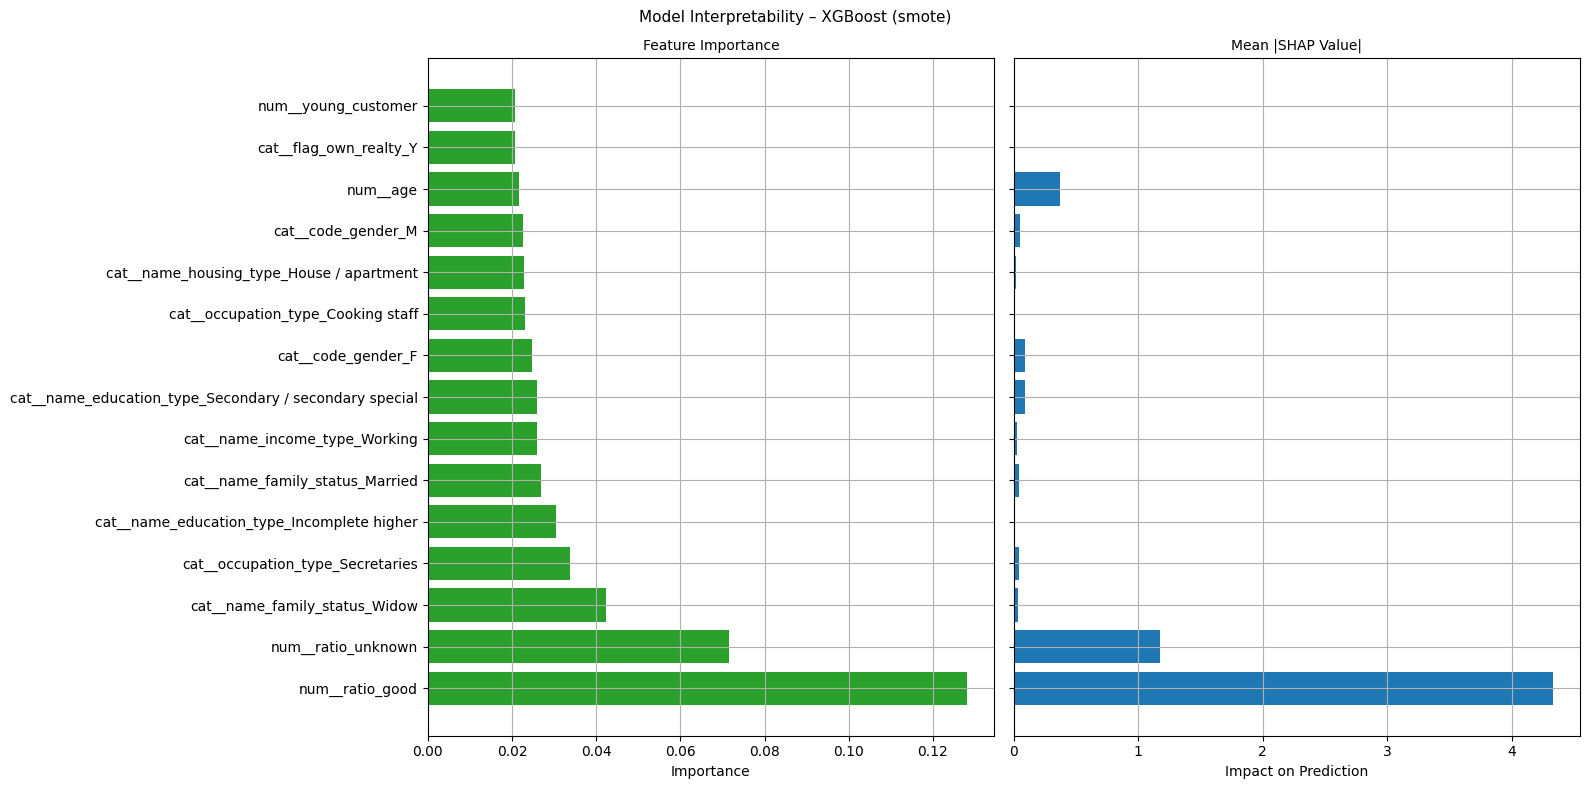

In [21]:
print("=" * 10, "MODEL INTERPRETATION AND SHAP ANALYSIS", "=" * 10)
# 1. Select best model (based on TEST AUC)
best_model_row = results_df.sort_values("roc_auc", ascending=False).iloc[0]
model_type_from_results = best_model_row["model"]
imbalance_type = best_model_row["imbalance_data"]

print(f"Best model: {model_type_from_results} ({imbalance_type})")
print(f"Test AUC: {best_model_row['roc_auc']:.4f}")

# 2. Convert model name for create_credit_model()
model_name_to_func_type = {
    "LogisticRegression": "logistic",
    "RandomForest": "random_forest",
    "LightGBM": "LightGBM",
    "XGBoost": "xgboost"
}

model_type = model_name_to_func_type.get(model_type_from_results, model_type_from_results)

# 3. Train best model
pipeline, _ = create_credit_model(model_type, imbalance_type)
pipeline.fit(x_train, y_train)
model = pipeline.named_steps["classifier"]
processor = pipeline.named_steps["preprocessor"]


# 4. Transform training data
x_train_trans = processor.transform(x_train)
try:
    feature_names = processor.get_feature_names_out()
except:
    feature_names = x_train.columns

# 5. SHAP for tree-based models
if isinstance(model, (lgb.LGBMClassifier, XGBClassifier, RandomForestClassifier, AdaBoostClassifier)):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x_train_trans)

    if isinstance(shap_values, list):  # binary classification
        shap_values = shap_values[1]
    mean_shap = np.abs(shap_values).mean(axis=0)

    df_imp = pd.DataFrame({
        "feature": feature_names,
        "importances": model.feature_importances_,
        "mean_SHAP": mean_shap
    }).sort_values("importances", ascending=False).head(15)

    print("\nTop 15 features from SHAP:")
    print(df_imp)

    # 6. Visualization
    fig, axes = plt.subplots(1,2,figsize=(16,8),sharey=True)

    # Feature Importance
    axes[0].barh(df_imp["feature"], df_imp["importances"], color="#2ca02c")
    axes[0].set_title("Feature Importance", fontsize=10)
    axes[0].set_xlabel("Importance", fontsize=10)
    axes[0].grid()

    # SHAP
    axes[1].barh(df_imp["feature"], df_imp["mean_SHAP"], color="#1f77b4")
    axes[1].set_title("Mean |SHAP Value|", fontsize=10)
    axes[1].set_xlabel("Impact on Prediction", fontsize=10)
    axes[1].grid()

    fig.suptitle(
        f"Model Interpretability – {model_type_from_results} ({imbalance_type})",
        fontsize=11)
    plt.tight_layout()
    plt.show()

else:
    print("SHAP interpretation is supported only for tree-based models.")